Using method from arXiv:2404.11110v2 and https://arxiv.org/abs/gr-qc/0304030v1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import cmath
import importlib
from scipy.optimize import root_scalar

# In my laptop, the files are saved in the folder /QNM_phase_amplitude, please modify this part if you want to use.
try:
    import QNM_phase_amplitude.qnm_functions as qnm_functions
except ModuleNotFoundError:
    import qnm_functions as qnm_functions

importlib.reload(qnm_functions)
globals().update({name: getattr(qnm_functions, name) for name in qnm_functions.__all__})

In [2]:
# Set up parameters used by qnm_functions.py
M = 1.0  # Mass of the black hole
l = 2    # Angular quantum number
s = 2    # Spin of the perturbation (s=0 for scalar, s=1 for electromagnetic, s=2 for gravitational)
set_parameters(M_value=M, l_value=l, s_value=s)


{'M': 1.0, 'l': 2, 's': 2}

In [ ]:
# define the GR QNM frequencies for l=2,3,4, s=2, n=0 (found by this program, with initial values of omega different from the following choice)

omega_qnm_2=0.37367139964832247-0.08896227650215158j
omega_qnm_3=0.5994435277105972-0.0927032103194887j
omega_qnm_4=0.8091803585360554-0.09416428274127403j


From latter program, we can see that the resolution of qnm frequencies is 1e-5 (in GR, different initial choices would lead to discrepancies of such order)

Also, from the following program, one can see that the numerical error of delta_Omega is indeed large.
Sometimes delta_Omega would have weird discrepancies from its mean value (I don't know why).
So we have to first determine what are "good" choices of epsilons. 

I assume that all the |omega_epsilon-omega_GR|<1e-3 results are invalid, but clearly this is not the only criterion. So I used two methods to select points. One is to select the points that gives the linear fit b closest to omega_qnm_2, and the other is to select the points that gives the lowest variance of delta_Omega. 

Actually, there is a concrete method to select delta_Omega, i.e. checking if the resonant condition is satisfied. The two methods just help us choosing reliable point easily.

# Verify GR QNM values

One can run to above box directly and skip this section

omega_ini is the initial guessed value

epsilon is deviation from GR

r_m is the middle point where we switch from P to P_tilde (sch coordinate)

rho_max is the maximun of integration (tortoise coordinate)

rho_min, r_m, rho_max have default values -50M, 3M, 10**4M respectively

points_per_period is the points within 2\pi/omega, in case the function oscillates too fast

delta is the initial separation between three Muller guessed values

tol is the termination condition for |A_in/A_out|

min_iter is chosen so that the function does not converge too quickly. max_iter is chosen so that the function terminates if the function does not converge.

This functions gaurantees that Muller intertion terminates only |F1|, |F2| satisfies < tol at the same time.


In [ ]:
l=2
set_parameters(l_value=l)
omega_qnm_2, ratio, zeta = find_QNM_muller(
    omega_ini=0.373 - 0.089j,
    epsilon=0.0,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.37367-0.08896j) A_in/A_out(z0) = (-1.848620281371902e-05+2.2774176600230085e-05j) |A_in/A_out(z0)| = 2.933262371981785e-05
z1 = (0.37377-0.08896j) A_in/A_out(z1) = (0.0009919977978213913+9.56472676728945e-05j) |A_in/A_out(z1)| = 0.000996598229326031
z2 = (0.37367-0.08886j) A_in/A_out(z2) = (2.679906310401037e-131+4.3956873976109594e-131j) |A_in/A_out(z2)| = 5.148200222412013e-131

Muller iteration 1
z0 = (0.37377-0.08896j) A_in/A_out(z0) = (0.0009919977978213913+9.56472676728945e-05j) |A_in/A_out(z0)| = 0.000996598229326031
z1 = (0.37367-0.08886j) A_in/A_out(z1) = (2.679906310401037e-131+4.3956873976109594e-131j) |A_in/A_out(z1)| = 5.148200222412013e-131
z2 = (0.37367-0.08886j) A_in/A_out(z2) = (2.679906310401037e-131+4.3956873976109594e-131j) |A_in/A_out(z2)| = 5.148200222412013e-131
|delta z| = 6.960555551807861e-132

Muller iteration 2
z0 = (0.37367-0.08886j) A_in/A_out(z0) = (2.679906310401037e-131+4.3956873976109594e-131j) |A_in/A_out(z0)| = 5.1482002224

In [8]:
l=3
set_parameters(l_value=l)
omega_qnm_3, ratio, zeta = find_QNM_muller(
    omega_ini=0.59944 - 0.09270j,
    epsilon=0.0,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.59944-0.0927j) A_in/A_out(z0) = (-0.0712109131925333-0.2307561655213247j) |A_in/A_out(z0)| = 0.24149410362122614
z1 = (0.59954-0.0927j) A_in/A_out(z1) = (-0.0007171199340449573+0.00022326523787226726j) |A_in/A_out(z1)| = 0.0007510714787866757
z2 = (0.59944-0.0926j) A_in/A_out(z2) = (-0.00023405571168715462-0.0007695486606702389j) |A_in/A_out(z2)| = 0.0008043551562044835

Muller iteration 1
z0 = (0.59954-0.0927j) A_in/A_out(z0) = (-0.0007171199340449573+0.00022326523787226726j) |A_in/A_out(z0)| = 0.0007510714787866757
z1 = (0.59944-0.0926j) A_in/A_out(z1) = (-0.00023405571168715462-0.0007695486606702389j) |A_in/A_out(z1)| = 0.0008043551562044835
z2 = (0.5994398324919948-0.09259983440502424j) A_in/A_out(z2) = (-0.00023345165673822435-0.000770768124541865j) |A_in/A_out(z2)| = 0.0008053466196884455
|delta z| = 2.3554326095883695e-07

Muller iteration 2
z0 = (0.59944-0.0926j) A_in/A_out(z0) = (-0.00023405571168715462-0.0007695486606702389j) |A_in/A_out(z0)| = 0.00

In [7]:
l=4
set_parameters(l_value=l)
omega_qnm_4, ratio, zeta = find_QNM_muller(
    omega_ini=0.80918 - 0.09416j,
    epsilon=0.0,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.80918-0.09416j) A_in/A_out(z0) = (1.6692952889947434e-05+2.3626838940655935e-05j) |A_in/A_out(z0)| = 2.8928916234689818e-05
z1 = (0.80928-0.09416j) A_in/A_out(z1) = (0.0005435051649393607-0.00040331412300177494j) |A_in/A_out(z1)| = 0.0006768014081903587
z2 = (0.80918-0.09405999999999999j) A_in/A_out(z2) = (0.0004374794640021156+0.0005332798395007632j) |A_in/A_out(z2)| = 0.0006897649372369823

Muller iteration 1
z0 = (0.80928-0.09416j) A_in/A_out(z0) = (0.0005435051649393607-0.00040331412300177494j) |A_in/A_out(z0)| = 0.0006768014081903587
z1 = (0.80918-0.09405999999999999j) A_in/A_out(z1) = (0.0004374794640021156+0.0005332798395007632j) |A_in/A_out(z1)| = 0.0006897649372369823
z2 = (0.8091803585360554-0.09416428274127403j) A_in/A_out(z2) = (-4.908255584515612e-131+1.5533810373229136e-131j) |A_in/A_out(z2)| = 5.148200222412013e-131
|delta z| = 0.00010428335761631341

Muller iteration 2
z0 = (0.80918-0.09405999999999999j) A_in/A_out(z0) = (0.0004374794640021156

# QNM frequencies \& Excitation factors, the potential delta V is obtained from https://arxiv.org/abs/2404.11110

## QNM frequencies

### For l=2

In [ ]:
# Try five epsilon values to find delta_Omega, with linear fit
l=2
set_parameters(l_value=l)
epsilon_list=[10**(-3), 10**(-2.8), 10**(-2.5), 10**(-2.2), 0.01]
omega_qnm_list_epsilon=find_QNM_list_muller(
    epsilon_list,
    omega_qnm_2,
    delta=None,
    tol=1e-10,
    max_iter=50,
    n_steps_min=20000,
    n_steps_max=50000,
    qnm_cutoff=100,
    verbose=False,
    use_previous_as_initial=True
)

Finding QNM for epsilon = 0.001
Muller found omega_qnm = (0.3739147494457242-0.08910914734601241j)
A_in/A_out_qnm = (-1.1931286061563616e-87+7.011517138860772e-88j)
zeta = (-159.95557775359876-158.27946040001652j)
|A_in/A_out_qnm| = 1.3838965267367376e-87
omega_qnm = (0.3739147494457242-0.08910914734601241j)
A_in/A_out = (-1.1931286061563616e-87+7.011517138860772e-88j)
zeta = (-159.95557775359876-158.27946040001652j)

Finding QNM for epsilon = 0.001584893192461114
Muller found omega_qnm = (0.37410463686701434-0.08926859549048416j)
A_in/A_out_qnm = (-1.0002982076584912e-87+9.563331493100173e-88j)
zeta = (-1.2843726937271573e+17-3.3119411447964396e+18j)
|A_in/A_out_qnm| = 1.3838965267367376e-87
omega_qnm = (0.37410463686701434-0.08926859549048416j)
A_in/A_out = (-1.0002982076584912e-87+9.563331493100173e-88j)
zeta = (-1.2843726937271573e+17-3.3119411447964396e+18j)

Finding QNM for epsilon = 0.0031622776601683794
Muller found omega_qnm = (0.37460463686702433-0.08926859549049417j)
A_in/A_

In [ ]:
for i in range(0,len(epsilon_list)):
    print(f"delta_Omega = {(omega_qnm_list_epsilon[i]-omega_qnm_2)/epsilon_list[i]}",omega_qnm_list_epsilon[i]-omega_qnm_2, abs(omega_qnm_list_epsilon[i]-omega_qnm_2), abs((omega_qnm_list_epsilon[i]-omega_qnm_2)/omega_qnm_2))

# From here, one can see that the choice of epsilon is important. It seems delta_Omega has the most sensible value for epsilon\sim 0.01, so let's see what happens around this value. But there is a weird discrepancy for epsilon\sim 0.006.

delta_Omega = (0.24474944572422386-0.24914734601241828j) (0.00024474944572422386-0.0002491473460124183j) 0.00034925161589797473
delta_Omega = (0.27423732342455714-0.25780632564247064j) (0.00043463686701433746-0.0004085954904841649j) 0.0005965395888053316
delta_Omega = (0.29555812849608026-0.12920923916352575j) (0.0009346368670243299-0.00040859549049417077j) 0.0010200472283444658
delta_Omega = (0.17277935769235256-0.1170133243802989j) (0.0010901640471056018-0.0007383041641979282j) 0.0013166437211613725
delta_Omega = (0.24739339956451056-0.15142207156028376j) (0.0024739339956451056-0.0015142207156028376j) 0.0029005540488619285


In [ ]:
# the linear fit value of delta_Omega and omega_qnm_GR using the above five epsilon values
k2, b2 = np.polyfit(epsilon_list, omega_qnm_list_epsilon, 1)

# k2 is delta_Omega; b2 \simeq omega_qnm_GR
print("k =", k2)
print("b =", b2)

k = (0.22606041993812923-0.13117468237715685j)
b = (0.3737083928688335-0.08894511535586035j)


In [ ]:
# Try epsilon=0.008
l=2
set_parameters(l_value=l)
omega_qnm_2_008, ratio, zeta = find_QNM_muller(
    omega_ini=omega_qnm_2,
    epsilon=0.008,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.37367-0.08886j) A_in/A_out(z0) = (-0.020268668502959553+0.010199784005635504j) |A_in/A_out(z0)| = 0.022690405828113398
z1 = (0.37377-0.08886j) A_in/A_out(z1) = (-0.019306712208842843+0.010312972457341928j) |A_in/A_out(z1)| = 0.02188850239785661
z2 = (0.37367-0.08875999999999999j) A_in/A_out(z2) = (-0.02037459969614956+0.011175762916859807j) |A_in/A_out(z2)| = 0.023238373212258134

Muller iteration 1
z0 = (0.37377-0.08886j) A_in/A_out(z0) = (-0.019306712208842843+0.010312972457341928j) |A_in/A_out(z0)| = 0.02188850239785661
z1 = (0.37367-0.08875999999999999j) A_in/A_out(z1) = (-0.02037459969614956+0.011175762916859807j) |A_in/A_out(z1)| = 0.023238373212258134
z2 = (0.37429460424138705-0.08954094144571877j) A_in/A_out(z2) = (-0.013592928019877541+0.00426735722850437j) |A_in/A_out(z2)| = 0.014247035827470937
|delta z| = 0.001

Muller iteration 2
z0 = (0.37367-0.08875999999999999j) A_in/A_out(z0) = (-0.02037459969614956+0.011175762916859807j) |A_in/A_out(z0)| = 0

In [66]:
# Try epsilon=0.012
l=2
set_parameters(l_value=l)
omega_qnm_2_012, ratio, zeta = find_QNM_muller(
    omega_ini=omega_qnm_2,
    epsilon=0.012,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.37367-0.08886j) A_in/A_out(z0) = (-0.030008409454264893+0.014377092981143475j) |A_in/A_out(z0)| = 0.03327469670129631
z1 = (0.37377-0.08886j) A_in/A_out(z1) = (-0.02908964240627818+0.014483274978947013j) |A_in/A_out(z1)| = 0.032495731249518454
z2 = (0.37367-0.08875999999999999j) A_in/A_out(z2) = (-0.03020690635711342+0.01533189718203379j) |A_in/A_out(z2)| = 0.033875127495964864

Muller iteration 1
z0 = (0.37377-0.08886j) A_in/A_out(z0) = (-0.02908964240627818+0.014483274978947013j) |A_in/A_out(z0)| = 0.032495731249518454
z1 = (0.37367-0.08875999999999999j) A_in/A_out(z1) = (-0.03020690635711342+0.01533189718203379j) |A_in/A_out(z1)| = 0.033875127495964864
z2 = (0.37466855862659404-0.08870632813349036j) A_in/A_out(z2) = (-0.020768155244831023+0.016990313807367787j) |A_in/A_out(z2)| = 0.026832574150577406
|delta z| = 0.001

Muller iteration 2
z0 = (0.37367-0.08875999999999999j) A_in/A_out(z0) = (-0.03020690635711342+0.01533189718203379j) |A_in/A_out(z0)| = 0.03

In [88]:
# Try epsilon=0.02
l=2
set_parameters(l_value=l)
omega_qnm_2_02, ratio, zeta = find_QNM_muller(
    omega_ini=omega_qnm_2,
    epsilon=0.02,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.37367-0.08886j) A_in/A_out(z0) = (-0.04890766603852691+0.021868510006128494j) |A_in/A_out(z0)| = 0.05357416846974128
z1 = (0.37377-0.08886j) A_in/A_out(z1) = (-0.04801627737019271+0.022016211633273143j) |A_in/A_out(z1)| = 0.052823067566853336
z2 = (0.37367-0.08875999999999999j) A_in/A_out(z2) = (-0.04905829512733958+0.022754060033500535j) |A_in/A_out(z2)| = 0.05407830959644815

Muller iteration 1
z0 = (0.37377-0.08886j) A_in/A_out(z0) = (-0.04801627737019271+0.022016211633273143j) |A_in/A_out(z0)| = 0.052823067566853336
z1 = (0.37367-0.08875999999999999j) A_in/A_out(z1) = (-0.04905829512733958+0.022754060033500535j) |A_in/A_out(z1)| = 0.05407830959644815
z2 = (0.37453196869160116-0.08926696151204941j) A_in/A_out(z2) = (-0.040618798152044264+0.01943085670805565j) |A_in/A_out(z2)| = 0.04502715797966274
|delta z| = 0.001

Muller iteration 2
z0 = (0.37367-0.08875999999999999j) A_in/A_out(z0) = (-0.04905829512733958+0.022754060033500535j) |A_in/A_out(z0)| = 0.0540

In [71]:
# put all the values together
epsilon_list.insert(5,0.008)
epsilon_list.append(0.012)
epsilon_list.append(0.02)
omega_qnm_list_epsilon.insert(5,omega_qnm_2_008)
omega_qnm_list_epsilon.append(omega_qnm_2_012)
omega_qnm_list_epsilon.append(omega_qnm_2_02)

In [144]:
for i in range(0,len(epsilon_list)):
    print(f"delta_Omega = {(omega_qnm_list_epsilon[i]-omega_qnm_2)/epsilon_list[i]}",omega_qnm_list_epsilon[i]-omega_qnm_2, abs(omega_qnm_list_epsilon[i]-omega_qnm_2), abs((omega_qnm_list_epsilon[i]-omega_qnm_2)/omega_qnm_2))

delta_Omega = (0.24334979740175955-0.1468708438608357j) (0.00024334979740175955-0.0001468708438608357j) 0.0002842361142991358 0.0007399759338671229
delta_Omega = (0.27335420503580893-0.19327421544218537j) (0.00043323721869187315-0.0003063189883325823j) 0.0005305900585885177 0.0013813300082319746
delta_Omega = (0.29511552083385817-0.09686656937211448j) (0.0009332372187018656-0.0003063189883425882j) 0.0009822235127452512 0.0025571056053242808
delta_Omega = (0.1725575283825412-0.10080359117942113j) (0.0010887643987831375-0.0006360276620463456j) 0.0012609278738079143 0.003282680257787825
delta_Omega = (0.2474627881577096-0.14081263528415572j) (0.001979702305261677-0.0011265010822732457j) 0.0022777677462421826 0.005929905562190889
delta_Omega = (0.24725343473226413-0.1411944213451255j) (0.0024725343473226413-0.001411944213451255j) 0.0028472816089366157 0.00741256920413073
delta_Omega = (0.24881256353549708-0.14138962159962812j) (0.002985750762425965-0.0016966754591955374j) 0.003434154223264

In [145]:
# Do the linear fit directly
k2, b2 = np.polyfit(epsilon_list, omega_qnm_list_epsilon, 1)

# k2 is delta_Omega; b2 \simeq omega_qnm_GR
print("k =", k2)
print("b =", b2)

k = (0.2505297931184058-0.14371145672249633j)
b = (0.373624244787246-0.08890666250154104j)


/media/luohan/Windows/Users/shjsf/PI/BH QNMs/.pyvenv/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
/media/luohan/Windows/Users/shjsf/PI/BH QNMs/.pyvenv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/media/luohan/Windows/Users/shjsf/PI/BH QNMs/.pyvenv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


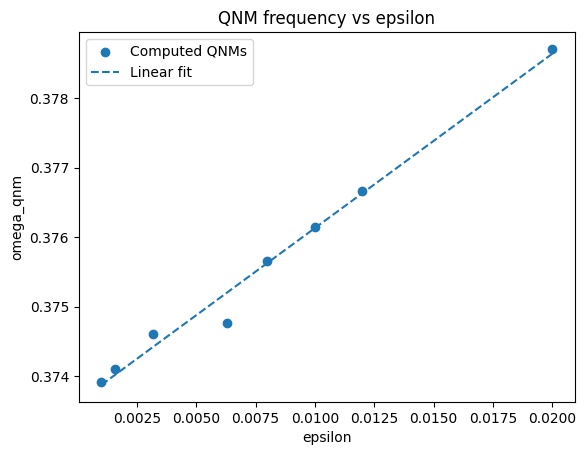

In [98]:
plt.scatter(epsilon_list, omega_qnm_list_epsilon, label="Computed QNMs")
plt.plot(epsilon_list, [k2*eps + b2 for eps in epsilon_list], label="Linear fit", linestyle="--")
plt.xlabel("epsilon")
plt.ylabel("omega_qnm")
plt.title("QNM frequency vs epsilon")
plt.legend()   

In [146]:
# two methods to select points. This selects the points that gives the linear fit b closest to omega_qnm_2
result = select_qnm_linear_fit_subset(
    epsilon_list,
    omega_qnm_list_epsilon,
    omega_qnm_2,
    min_points=3,
    subset_mode="all",        # or "contiguous"
)

print("selected indices =", result["selected_indices"])
print("selected epsilons =", result["epsilon_selected"])
print("selected omegas =", result["omega_selected"])

print("final k (with b fixed to omega_qnm_2) =", result["k"])
print("free-fit b =", result["b_free"])
print("|b_free - omega_qnm_2| =", result["intercept_error"])
print("RMSE with fixed intercept =", result["rmse_fixed"])

selected indices = [0, 4, 5]
selected epsilons = [0.001, 0.008, 0.01]
selected omegas = [(0.3739147494457242-0.08910914734601241j), (0.37565110195358414-0.09008877758442482j), (0.3761439339956451-0.09037422071560283j)]
final k (with b fixed to omega_qnm_2) = (0.24731098007710056-0.1410807371912688j)
free-fit b = (0.37366730891478483-0.08896816494944222j)
|b_free - omega_qnm_2| = 7.169931127326359e-06
RMSE with fixed intercept = 4.355648273488993e-06


In [147]:
# This selects the points that gives the lowest variance of delta_Omega
result = select_qnm_low_variance_subset(
    epsilon_list,
    omega_qnm_list_epsilon,
    omega_qnm_2,
    min_points=3,
    min_relative_variance_reduction=0.05,
    min_sigma_distance=1.5,
)

print("selected indices =", result["selected_indices"])
print("removed indices =", result["removed_indices"])
print("selected epsilons =", result["epsilon_selected"])
print("selected omegas =", result["omega_selected"])
print("delta_Omega =", result["k"])
print("delta_Omega std =", result["delta_omega_std"])

selected indices = [4, 5, 6]
removed indices = [0, 1, 2, 3, 7]
selected epsilons = [0.008, 0.01, 0.012]
selected omegas = [(0.37565110195358414-0.09008877758442482j), (0.3761439339956451-0.09037422071560283j), (0.37665715041074843-0.09065895196134711j)]
delta_Omega = (0.24802588007932275-0.14120635163326287j)
delta_Omega std = 0.0007313140377467133


In [148]:
for step in result["removal_history"]:
    print(
        "removed epsilon =", step["epsilon_removed"],
        "relative variance reduction =", step["relative_variance_reduction"],
        "sigma distance =", step["sigma_distance"],
    )

removed epsilon = 0.00630957344480193 relative variance reduction = 0.4718025694993432 sigma distance = 1.9403068670144616
removed epsilon = 0.0031622776601683794 relative variance reduction = 0.530789996978805 sigma distance = 1.8939165727302838
removed epsilon = 0.001584893192461114 relative variance reduction = 0.9734106898647409 sigma distance = 2.2111560794683327
removed epsilon = 0.001 relative variance reduction = 0.7280830806492968 sigma distance = 1.7691426901405476
removed epsilon = 0.02 relative variance reduction = 0.8391481189020261 sigma distance = 1.624217740184344


For l=2, the results from two selection methods are different. But anyway, delta_Omega_l2 is around 0.248 -0.14i

### For l = 3

In [ ]:
# Use 3 epsilon values to find delta_Omega, with linear fit
l=3
set_parameters(l_value=l)
epsilon_list_3=[10**(-3), 0.005, 0.01]
omega_qnm_list_epsilon_3=find_QNM_list_muller(
    epsilon_list_3,
    omega_qnm_3,
    delta=1e-4,
    tol=1e-7,
    max_iter=50,
    n_steps_min=80000,
    n_steps_max=None,
    qnm_cutoff=150,
    points_per_period=150,
    max_step=1e-3,
    verbose=False,
    use_previous_as_initial=True
)

Finding QNM for epsilon = 0.001
Muller found omega_qnm = (0.5995587802807177-0.09271088894671728j)
A_in/A_out_qnm = (4.1931850254868287e-131+2.9868319122568864e-131j)
zeta = (6245921737.578552-212040442.27539268j)
|A_in/A_out_qnm| = 5.148200222412013e-131
omega_qnm = (0.5995587802807177-0.09271088894671728j)
A_in/A_out = (4.1931850254868287e-131+2.9868319122568864e-131j)
zeta = (6245921737.578552-212040442.27539268j)

Finding QNM for epsilon = 0.005
Muller found omega_qnm = (0.6011549003740739-0.09341409606218931j)
A_in/A_out_qnm = (5.146597442705742e-131+1.2845346541769315e-132j)
zeta = (407090546884227.3-43177146937960.79j)
|A_in/A_out_qnm| = 5.148200222412013e-131
omega_qnm = (0.6011549003740739-0.09341409606218931j)
A_in/A_out = (5.146597442705742e-131+1.2845346541769315e-132j)
zeta = (407090546884227.3-43177146937960.79j)

Finding QNM for epsilon = 0.01
Muller found omega_qnm = (0.6028742109906259-0.09412561654627548j)
A_in/A_out_qnm = (-3.22001805656498e-08+3.686555868381068e-08j

In [112]:
# The deviation seems to be smaller than l=2. Try larger epsilon. the first set of data is apparently too small to be considered
for i in range(len(epsilon_list_3)):
    print(f"delta_Omega = {(omega_qnm_list_epsilon_3[i]-omega_qnm_3)/epsilon_list_3[i]}",omega_qnm_list_epsilon_3[i]-omega_qnm_3, abs(omega_qnm_list_epsilon_3[i]-omega_qnm_3), abs((omega_qnm_list_epsilon_3[i]-omega_qnm_3)/omega_qnm_3))

delta_Omega = (0.09999999999998899+0j) (9.999999999998899e-05+0j) 9.999999999998899e-05 0.00016485718333813222
delta_Omega = (0.33922401867123586-0.14064142309440641j) (0.0016961200933561793-0.0007032071154720321j) 0.0018361164501025174 0.0030269698624474455
delta_Omega = (0.34154307099081294-0.14147275995581993j) (0.0034154307099081294-0.0014147275995581993j) 0.0036968393412664356 0.006094505210548479
delta_Omega = (0.34495094068622095-0.14160926300697033j) (0.010348528220586628-0.0042482778902091095j) 0.011186594717103029 0.018441904962070384
delta_Omega = (0.2916007884996463-0.10791011253547977j) (0.014580039424982316-0.005395505626773989j) 0.015546351038188622 0.025629276433419064


In [ ]:
# try large epsilons
l=3
set_parameters(l_value=l)
epsilon_list_3_2=[0.03,0.05]
omega_qnm_list_epsilon_3_2=find_QNM_list_muller(
    epsilon_list_3_2,
    omega_qnm_3,
    delta=1e-4,
    tol=1e-7,
    max_iter=50,
    n_steps_min=80000,
    n_steps_max=None,
    qnm_cutoff=150,
    points_per_period=150,
    max_step=1e-3,
    verbose=False,
    use_previous_as_initial=True
)

Finding QNM for epsilon = 0.03
Muller found omega_qnm = (0.6098073085013044-0.09695916683692639j)
A_in/A_out_qnm = (2.089375022207782e-131-4.705154359488893e-131j)
zeta = (6.26898829967032e+71-1.5741844796428469e+72j)
|A_in/A_out_qnm| = 5.148200222412013e-131
omega_qnm = (0.6098073085013044-0.09695916683692639j)
A_in/A_out = (2.089375022207782e-131-4.705154359488893e-131j)
zeta = (6.26898829967032e+71-1.5741844796428469e+72j)

Finding QNM for epsilon = 0.05
Muller found omega_qnm = (0.6140388197057001-0.09810639457349127j)
A_in/A_out_qnm = (-8.691651463671424e-132-5.074299703248094e-131j)
zeta = (-72505.5174296497-137347.29164569243j)
|A_in/A_out_qnm| = 5.148200222412013e-131
omega_qnm = (0.6140388197057001-0.09810639457349127j)
A_in/A_out = (-8.691651463671424e-132-5.074299703248094e-131j)
zeta = (-72505.5174296497-137347.29164569243j)



In [ ]:
# connect them two
epsilon_list_3=epsilon_list_3+epsilon_list_3_2
omega_qnm_list_epsilon_3=omega_qnm_list_epsilon_3+omega_qnm_list_epsilon_3_2

In [113]:
for i in range(len(epsilon_list_3)):
    print(f"delta_Omega = {(omega_qnm_list_epsilon_3[i]-omega_qnm_3)/epsilon_list_3[i]}",omega_qnm_list_epsilon_3[i]-omega_qnm_3,abs(omega_qnm_list_epsilon_3[i]-omega_qnm_3))

delta_Omega = (0.09999999999998899+0j) (9.999999999998899e-05+0j) 9.999999999998899e-05
delta_Omega = (0.33922401867123586-0.14064142309440641j) (0.0016961200933561793-0.0007032071154720321j) 0.0018361164501025174
delta_Omega = (0.34154307099081294-0.14147275995581993j) (0.0034154307099081294-0.0014147275995581993j) 0.0036968393412664356
delta_Omega = (0.34495094068622095-0.14160926300697033j) (0.010348528220586628-0.0042482778902091095j) 0.011186594717103029
delta_Omega = (0.2916007884996463-0.10791011253547977j) (0.014580039424982316-0.005395505626773989j) 0.015546351038188622


In [115]:
# remove the first point, which is too small to be considered
epsilon_list_3=np.delete(epsilon_list_3,0)

omega_qnm_list_epsilon_3=np.delete(omega_qnm_list_epsilon_3,0)

In [136]:
# Do the linear fit directly
k3, b3 = np.polyfit(epsilon_list_3, omega_qnm_list_epsilon_3, 1)

print("k3 =", k3)
print("b3 =", b3)

k3 = (0.29055362543668134-0.10683438156263912j)
b3 = (0.6000681612888046-0.0931140019426079j)


/media/luohan/Windows/Users/shjsf/PI/BH QNMs/.pyvenv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/media/luohan/Windows/Users/shjsf/PI/BH QNMs/.pyvenv/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
/media/luohan/Windows/Users/shjsf/PI/BH QNMs/.pyvenv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


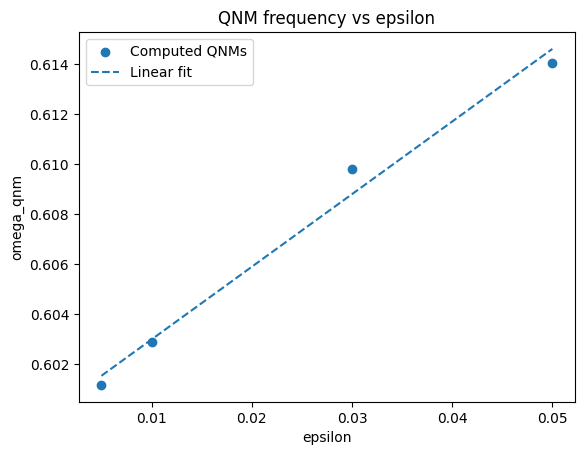

In [137]:
plt.scatter(epsilon_list_3, omega_qnm_list_epsilon_3, label="Computed QNMs")
plt.plot(epsilon_list_3, [k3*eps + b3 for eps in epsilon_list_3], label="Linear fit", linestyle="--")
plt.xlabel("epsilon")
plt.ylabel("omega_qnm")
plt.title("QNM frequency vs epsilon")
plt.legend()   

In [119]:
# two methods to select points. This selects the points that gives the linear fit b closest to omega_qnm_3
result = select_qnm_linear_fit_subset(
    epsilon_list_3,
    omega_qnm_list_epsilon_3,
    omega_qnm_3,
    min_points=3,
    subset_mode="all",        # or "contiguous"
)

print("selected indices =", result["selected_indices"])
print("selected epsilons =", result["epsilon_selected"])
print("selected omegas =", result["omega_selected"])

print("final k (with b fixed to omega_qnm_3) =", result["k"])
print("free-fit b =", result["b_free"])
print("|b_free - omega_qnm_3| =", result["intercept_error"])
print("RMSE with fixed intercept =", result["rmse_fixed"])

selected indices = [0, 1, 2]
selected epsilons = [0.005, 0.01, 0.03]
selected omegas = [(0.6011549003740739-0.09341409606218931j), (0.6028742109906259-0.09412561654627548j), (0.6098073085013044-0.09695916683692639j)]
final k (with b fixed to omega_qnm_3) = (0.3444787845692303-0.14157233978460043j)
free-fit b = (0.5994183012913761-0.09270645442081786j)
|b_free - omega_qnm_3| = 4.072116891834052e-05
RMSE with fixed intercept = 2.4335690865451835e-05


In [117]:
# This selects the points that gives the lowest variance of delta_Omega
result = select_qnm_low_variance_subset(
    epsilon_list_3,
    omega_qnm_list_epsilon_3,
    omega_qnm_3,
    min_points=3,
    min_relative_variance_reduction=0.05,
    min_sigma_distance=1.5,
)

print("selected indices =", result["selected_indices"])
print("removed indices =", result["removed_indices"])
print("selected epsilons =", result["epsilon_selected"])
print("selected omegas =", result["omega_selected"])
print("delta_Omega =", result["k"])
print("delta_Omega std =", result["delta_omega_std"])

selected indices = [0, 1, 2]
removed indices = [3]
selected epsilons = [0.005, 0.01, 0.03]
selected omegas = [(0.6011549003740739-0.09341409606218931j), (0.6028742109906259-0.09412561654627548j), (0.6098073085013044-0.09695916683692639j)]
delta_Omega = (0.3444787845692303-0.14157233978460043j)
delta_Omega std = 0.0023906225001499087


In [118]:
for step in result["removal_history"]:
    print(
        "removed epsilon =", step["epsilon_removed"],
        "relative variance reduction =", step["relative_variance_reduction"],
        "sigma distance =", step["sigma_distance"],
    )

removed epsilon = 0.05 relative variance reduction = 0.991682096509234 sigma distance = 1.7266397183969153


Two methods of selecting points give the same result for l=3, delta_Omega_l3 = 0.3444787845692303-0.14157233978460043j

### For l = 4

In [ ]:
# Use five epsilon values to find delta_Omega, with linear fit
l=4
set_parameters(l_value=l)
epsilon_list_4=[10**(-2.8), 10**(-2.5), 10**(-2.2)]
omega_qnm_list_epsilon_4=find_QNM_list_muller(
    epsilon_list_4,
    omega_qnm_4,
    delta=None,
    tol=1e-10,
    max_iter=50,
    n_steps_min=20000,
    n_steps_max=50000,
    qnm_cutoff=100,
    verbose=False,
    use_previous_as_initial=True
)

Finding QNM for epsilon = 0.001584893192461114
Muller found omega_qnm = (0.8091803585360754-0.09416428274129404j)
A_in/A_out_qnm = (-9.5618389176467e-88-1.000440883732655e-87j)
zeta = (183855489.29388186-137193180.70630434j)
|A_in/A_out_qnm| = 1.3838965267367376e-87
omega_qnm = (0.8091803585360754-0.09416428274129404j)
A_in/A_out = (-9.5618389176467e-88-1.000440883732655e-87j)
zeta = (183855489.29388186-137193180.70630434j)

Finding QNM for epsilon = 0.0031622776601683794
Muller found omega_qnm = (0.8091803585360854-0.09416428274130405j)
A_in/A_out_qnm = (-1.2010180833105369e-87-6.875501147371661e-88j)
zeta = (1334.9169113237735-2142.687544795388j)
|A_in/A_out_qnm| = 1.3838965267367376e-87
omega_qnm = (0.8091803585360854-0.09416428274130405j)
A_in/A_out = (-1.2010180833105369e-87-6.875501147371661e-88j)
zeta = (1334.9169113237735-2142.687544795388j)

Finding QNM for epsilon = 0.00630957344480193
Muller found omega_qnm = (0.8091803585361154-0.09366428274131405j)
A_in/A_out_qnm = (3.9025

In [ ]:
for i in range(len(epsilon_list_4)):
    print(f"delta_Omega = {(omega_qnm_list_epsilon_4[i]-omega_qnm_4)/epsilon_list_4[i]}", omega_qnm_list_epsilon_4[i]-omega_qnm_4)
# the discrepencies for l=4 are smaller, sadly, none of these three choices of epsilon are reliable, so we need to try larger epsilon values and discard these ones.

delta_Omega = (6.30453034258431e-12-6.313286634726789e-12j) (9.992007221626409e-15-1.0005885009434223e-14j)
delta_Omega = (6.3195002434380614e-12-6.3282773271095035e-12j) (1.9984014443252818e-14-2.0011770018868447e-14j)
delta_Omega = (7.918132112288992e-12+0.0792446596182983j) (4.9960036108132044e-14+0.0004999999999699828j)


In [ ]:
# try 0.01

l = 4
set_parameters(l_value=l)

omega_qnm_4_epsilon, ratio, zeta = find_QNM_muller(
    omega_ini=0.80918 - 0.09416j,
    epsilon=0.01,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,
    points_per_period=150,
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

print("omega_qnm =", omega_qnm_4_epsilon)
print("A_in/A_out =", ratio)
print("zeta =", zeta)

Muller iteration 0
z0 = (0.80918-0.09416j) A_in/A_out(z0) = (-0.01730951425966229+0.023721671604751422j) |A_in/A_out(z0)| = 0.0293655748731252
z1 = (0.80928-0.09416j) A_in/A_out(z1) = (-0.01675522168361294+0.023378734530291156j) |A_in/A_out(z1)| = 0.02876286984820606
z2 = (0.80918-0.09405999999999999j) A_in/A_out(z2) = (-0.01679390443044618+0.02429842746488179j) |A_in/A_out(z2)| = 0.02953724434142565

Muller iteration 1
z0 = (0.80928-0.09416j) A_in/A_out(z0) = (-0.01675522168361294+0.023378734530291156j) |A_in/A_out(z0)| = 0.02876286984820606
z1 = (0.80918-0.09405999999999999j) A_in/A_out(z1) = (-0.01679390443044618+0.02429842746488179j) |A_in/A_out(z1)| = 0.02953724434142565
z2 = (0.8095356677323978-0.09312538753264733j) A_in/A_out(z2) = (-1.0362003782876373e-131+5.04284188787232e-131j) |A_in/A_out(z2)| = 5.148200222412013e-131
|delta z| = 0.0009999999999999998

Muller iteration 2
z0 = (0.80918-0.09405999999999999j) A_in/A_out(z0) = (-0.01679390443044618+0.02429842746488179j) |A_in/A_

In [ ]:
print(((0.8095356677324078-0.09312538753265734j) - omega_qnm_4)/0.01, (0.8095356677324078-0.09312538753265734j) - omega_qnm_4)

(0.035530919634241265+0.10388952086266973j) (0.00035530919634241265+0.0010388952086266973j)


In [ ]:
#try 0.005

l = 4
set_parameters(l_value=l)

omega_qnm_4_epsilon005, ratio, zeta = find_QNM_muller(
    omega_ini=0.80918 - 0.09416j,
    epsilon=0.005,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,
    points_per_period=150,
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

print("omega_qnm =", omega_qnm_4_epsilon005)
print("A_in/A_out =", ratio)
print("zeta =", zeta)

Muller iteration 0
z0 = (0.80918-0.09416j) A_in/A_out(z0) = (-0.008587268662637558+0.012346720761876321j) |A_in/A_out(z0)| = 0.015039371551233941
z1 = (0.80928-0.09416j) A_in/A_out(z1) = (-0.008057548610433308+0.012020483950345969j) |A_in/A_out(z1)| = 0.014471217088069019
z2 = (0.80918-0.09405999999999999j) A_in/A_out(z2) = (-0.008174985570888029+0.012822716187681537j) |A_in/A_out(z2)| = 0.015206986536262127

Muller iteration 1
z0 = (0.80928-0.09416j) A_in/A_out(z0) = (-0.008057548610433308+0.012020483950345969j) |A_in/A_out(z0)| = 0.014471217088069019
z1 = (0.80918-0.09405999999999999j) A_in/A_out(z1) = (-0.008174985570888029+0.012822716187681537j) |A_in/A_out(z1)| = 0.015206986536262127
z2 = (0.8096025479351376-0.0949663405775485j) A_in/A_out(z2) = (-0.009473801417996653+0.006637404363400692j) |A_in/A_out(z2)| = 0.011567542953926126
|delta z| = 0.001

Muller iteration 2
z0 = (0.80918-0.09405999999999999j) A_in/A_out(z0) = (-0.008174985570888029+0.012822716187681537j) |A_in/A_out(z0)|

In [ ]:
print((omega_qnm_4_epsilon005 - omega_qnm_4)/0.005, omega_qnm_4_epsilon005 - omega_qnm_4)

(0.444001930564597-0.1453580244177688j) (0.002220009652822985-0.000726790122088844j)


In [ ]:
# try 0.003
l = 4
set_parameters(l_value=l)

omega_qnm_4_epsilon, ratio, zeta = find_QNM_muller(
    omega_ini=omega_qnm_4,
    epsilon=10**(-2.5),
    delta=1e-4 * max(1.0, abs(omega_qnm_4)),
    r_m=3*M,
    rho_max=2*10**4*M,
    n_steps_min=80000,
    n_steps_max=None,
    points_per_period=200,
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,omega_qnm_4_epsilon
    verbose=True,
    print_termination=False
)

print("omega_qnm =", omega_qnm_4_epsilon)
print("A_in/A_out =", ratio)
print("zeta =", zeta)

Muller iteration 0
z0 = (0.8091803585360654-0.09416428274128404j) A_in/A_out(z0) = (-0.005443102030003203+0.00791471252152723j) |A_in/A_out(z0)| = 0.009605729228301458
z1 = (0.8092803585360654-0.09416428274128404j) A_in/A_out(z1) = (-0.004919408327918455+0.007526791913313666j) |A_in/A_out(z1)| = 0.008991839344823584
z2 = (0.8091803585360654-0.09406428274128403j) A_in/A_out(z2) = (-0.005046621419427115+0.008446498188287603j) |A_in/A_out(z2)| = 0.009839294659464483

Muller iteration 1
z0 = (0.8092803585360654-0.09416428274128404j) A_in/A_out(z0) = (-0.004919408327918455+0.007526791913313666j) |A_in/A_out(z0)| = 0.008991839344823584
z1 = (0.8091803585360654-0.09406428274128403j) A_in/A_out(z1) = (-0.005046621419427115+0.008446498188287603j) |A_in/A_out(z1)| = 0.009839294659464483
z2 = (0.810141185423625-0.09434143196488491j) A_in/A_out(z2) = (-0.001142014771998855+0.0032229663623072505j) |A_in/A_out(z2)| = 0.003419314245872647
|delta z| = 0.001

Muller iteration 2
z0 = (0.8091803585360654

In [ ]:
print((omega_qnm_4_epsilon - omega_qnm_4)/10**(-2.5), omega_qnm_4_epsilon - omega_qnm_4)

(0.3051666121149417-0.05594258582262608j) (0.0009650215601203493-0.00017690598939894275j)


In [123]:
#try 0.02, 0.03
l=4
set_parameters(l_value=l)
epsilon_list_4=[0.02, 0.03]
omega_qnm_list_epsilon_4=find_QNM_list_muller(
    epsilon_list_4,
    omega_qnm_4,
    delta=1e-4,
    tol=1e-7,
    rho_max=10**4*M,
    max_iter=50,
    n_steps_min=20000,
    n_steps_max=None,
    points_per_period=150,
    qnm_cutoff=150,
    verbose=True,
    use_previous_as_initial=True
)

Finding QNM for epsilon = 0.02
Muller iteration 0
z0 = (0.8091803585360654-0.09416428274128404j) A_in/A_out(z0) = (-0.034755819879218004+0.04368166002644322j) |A_in/A_out(z0)| = 0.05582163055789765
z1 = (0.8092803585360654-0.09416428274128404j) A_in/A_out(z1) = (-0.03423151544609539+0.04343213621807767j) |A_in/A_out(z1)| = 0.05530051632852917
z2 = (0.8091803585360654-0.09406428274128403j) A_in/A_out(z2) = (-0.0344899392912201+0.044201306559032705j) |A_in/A_out(z2)| = 0.056065242475509154

Muller iteration 1
z0 = (0.8092803585360654-0.09416428274128404j) A_in/A_out(z0) = (-0.03423151544609539+0.04343213621807767j) |A_in/A_out(z0)| = 0.05530051632852917
z1 = (0.8091803585360654-0.09406428274128403j) A_in/A_out(z1) = (-0.0344899392912201+0.044201306559032705j) |A_in/A_out(z1)| = 0.056065242475509154
z2 = (0.8099347803121629-0.09591653752498681j) A_in/A_out(z2) = (-0.035697567085965665+0.032785818248801064j) |A_in/A_out(z2)| = 0.0484688165122735
|delta z| = 0.002

Muller iteration 2
z0 = (

In [127]:
for i in range(len(epsilon_list_4)):
    print(omega_qnm_list_epsilon_4[i], f"delta_Omega = {(omega_qnm_list_epsilon_4[i]-omega_qnm_4)/epsilon_list_4[i]}", omega_qnm_list_epsilon_4[i]-omega_qnm_4, abs(omega_qnm_list_epsilon_4[i]-omega_qnm_4), abs((omega_qnm_list_epsilon_4[i]-omega_qnm_4)/omega_qnm_4))

(0.8180335282794574-0.09701130577732757j) delta_Omega = (0.44265848716960043-0.14235115180217667j) (0.008853169743392009-0.0028470230360435334j) 0.009299685729801532 0.01141568751112672
(0.8224308589238158-0.09841699513116291j) delta_Omega = (0.44168334625834804-0.14175707966262904j) (0.013250500387750441-0.004252712389878871j) 0.013916225177712663 0.017082650164634325


In [128]:
# put all the epsilon and omega for l=4 together

epsilon_list_4=[10**(-2.5),0.005,0.01,0.02,0.03]
omega_qnm_list_epsilon_4=[0.8101453800961858-0.09434118873068298j,0.8114003681888884-0.09489107286337288j,0.8095356677324078-0.09312538753265734j,0.8180335282794574-0.09701130577732757j,0.8224308589238158-0.09841699513116291j]

In [130]:
for i in range(len(epsilon_list_4)):
    print(f"delta_Omega = {(omega_qnm_list_epsilon_4[i]-omega_qnm_4)/epsilon_list_4[i]}", omega_qnm_list_epsilon_4[i]-omega_qnm_4, abs(omega_qnm_list_epsilon_4[i]-omega_qnm_4), abs((omega_qnm_list_epsilon_4[i]-omega_qnm_4)/omega_qnm_4))

delta_Omega = (0.3051666121149417-0.05594258582262608j) (0.0009650215601203493-0.00017690598939894275j) 0.000981102614705685 0.0012043375648639772
delta_Omega = (0.444001930564597-0.1453580244177688j) (0.002220009652822985-0.000726790122088844j) 0.0023359509284642836 0.0028674609675485964
delta_Omega = (0.035530919634241265+0.10388952086266973j) (0.00035530919634241265+0.0010388952086266973j) 0.0010979744439252672 0.0013478017979561845
delta_Omega = (0.44265848716960043-0.14235115180217667j) (0.008853169743392009-0.0028470230360435334j) 0.009299685729801532 0.01141568751112672
delta_Omega = (0.44168334625834804-0.14175707966262904j) (0.013250500387750441-0.004252712389878871j) 0.013916225177712663 0.017082650164634325


In [129]:
## Do the linear fit directly

k4, b4 = np.polyfit(epsilon_list_4, omega_qnm_list_epsilon_4, 1)

print("k =", k4)
print("b =", b4)

k = (0.47983709284621107-0.16485902223984525j)
b = (0.807767802813305-0.09330975671730149j)


/media/luohan/Windows/Users/shjsf/PI/BH QNMs/.pyvenv/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
/media/luohan/Windows/Users/shjsf/PI/BH QNMs/.pyvenv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/media/luohan/Windows/Users/shjsf/PI/BH QNMs/.pyvenv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


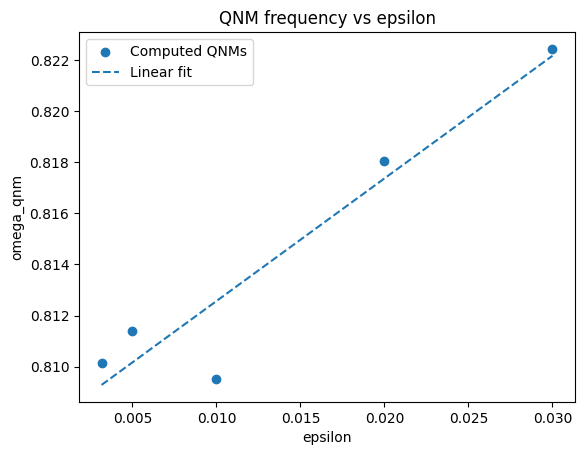

In [132]:
plt.scatter(epsilon_list_4, omega_qnm_list_epsilon_4, label="Computed QNMs")
plt.plot(epsilon_list_4, [k4*eps + b4 for eps in epsilon_list_4], label="Linear fit", linestyle="--")
plt.xlabel("epsilon")
plt.ylabel("omega_qnm")
plt.title("QNM frequency vs epsilon")
plt.legend()   

In [133]:
# two methods to select points. This selects the points that gives the linear fit b closest to omega_qnm_2
result = select_qnm_linear_fit_subset(
    epsilon_list_4,
    omega_qnm_list_epsilon_4,
    omega_qnm_4,
    min_points=3,
    subset_mode="all",        # or "contiguous"
)

print("selected indices =", result["selected_indices"])
print("selected epsilons =", result["epsilon_selected"])
print("selected omegas =", result["omega_selected"])

print("final k (with b fixed to omega_qnm_2) =", result["k"])
print("free-fit b =", result["b_free"])
print("|b_free - omega_qnm_2| =", result["intercept_error"])
print("RMSE with fixed intercept =", result["rmse_fixed"])

selected indices = [1, 3, 4]
selected epsilons = [0.005, 0.02, 0.03]
selected omegas = [(0.8114003681888884-0.09489107286337288j), (0.8180335282794574-0.09701130577732757j), (0.8224308589238158-0.09841699513116291j)]
final k (with b fixed to omega_qnm_2) = (0.44202147529393837-0.1420043645491932j)
free-fit b = (0.8091977908536533-0.09418699672506553j)
|b_free - omega_qnm_2| = 2.8632337587260497e-05
RMSE with fixed intercept = 1.578588087610813e-05


In [134]:
# This selects the points that gives the lowest variance of delta_Omega
result = select_qnm_low_variance_subset(
    epsilon_list_4,
    omega_qnm_list_epsilon_4,
    omega_qnm_4,
    min_points=3,
    min_relative_variance_reduction=0.05,
    min_sigma_distance=1.5,
)

print("selected indices =", result["selected_indices"])
print("removed indices =", result["removed_indices"])
print("selected epsilons =", result["epsilon_selected"])
print("selected omegas =", result["omega_selected"])
print("delta_Omega =", result["k"])
print("delta_Omega std =", result["delta_omega_std"])

selected indices = [1, 3, 4]
removed indices = [0, 2]
selected epsilons = [0.005, 0.02, 0.03]
selected omegas = [(0.8114003681888884-0.09489107286337288j), (0.8180335282794574-0.09701130577732757j), (0.8224308589238158-0.09841699513116291j)]
delta_Omega = (0.44202147529393837-0.1420043645491932j)
delta_Omega std = 0.0018406695913442549


In [135]:
for step in result["removal_history"]:
    print(
        "removed epsilon =", step["epsilon_removed"],
        "relative variance reduction =", step["relative_variance_reduction"],
        "sigma distance =", step["sigma_distance"],
    )

removed epsilon = 0.01 relative variance reduction = 0.855007929411964 sigma distance = 1.8804322306635475
removed epsilon = 0.0031622776601683794 relative variance reduction = 0.999319599668902 sigma distance = 1.7316088181962541


For l=4, the two selection methods give the same choice. delta_omega_l4=0.44202147529393837-0.1420043645491932j

We can see that this method also works better for higher l.

## Compute the excitation factor 

## Check GR excitation factors

In [149]:
# Compute the excitation factor for l=2, GR, using omega_qnm_2
l=2
set_parameters(l_value=l)

list=calculate_Bn(
    omega_n=omega_qnm_2,
    epsilon=0.,
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    label_R_plus="+",
    label_R_minus="-",
    domega_step=1e-6,
    steps_per_period=150,
    verbose=True
)

PL_initial = (-0.08896227921974481-0.37367140053100417j)
boundary condition= + P_R = (0.0889622719673424+0.37367138062670796j)
boundary condition= - P_R = (-0.0889622719673424-0.37367138062670796j)
beta = 0.23372518843019108
r_min = (1.9999999995302953+5.8347319517594284e-09j)
r_max = (19439.402504650323+4631.592641233641j)
r_m_check_left = (2.999999999609869-7.849981184288209e-09j)
r_m_check_right = (3.000000002974966+6.977535618735153e-09j)
x_m = (1.6137056388801094+0j)
x_max = (19457.8213445598+4632.060482247098j)
P_L,-(rho_m) = (0.022909080337197487-0.07029852859600332j)
Omega_L,-(rho_m) = (-1.243905137430407-1.3597850586825724j)
Ptilde_R,+(rho_m) = (-2.2765854933237133+0.3075578758325787j)
Ptilde_R,-(rho_m) = (1.5164987290551764+0.6332426606951168j)
P_R,+(rho_m) = (0.022907799985383958-0.07029936031856583j)
P_R,-(rho_m) = (-0.21989770230821415-0.17627500485976483j)
phi_R,+(rho_m) = (0.03500862268903405-7679.428227097216j)
phi_R,-(rho_m) = (1.0296339590117434+7680.353758235317j)
Om

In [157]:
abs(list["PLminus_m"]-list["PRplus_m"])

np.float64(1.5267819711426129e-06)

resonant condition is satisfied

In [159]:
omega_qnm_3

(0.5994435277105972-0.0927032103194887j)

In [165]:
# Compute the excitation factor for l=3, GR, using omega_qnm_3

l=3
set_parameters(l_value=l)

list3=calculate_Bn(
    omega_n=omega_qnm_3,
    epsilon=0.,
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    label_R_plus="+",
    label_R_minus="-",
    domega_step=1e-6,
    steps_per_period=150,
    verbose=True
)

PL_initial = (-0.09270320937825043-0.5994435315838972j)
boundary condition= + P_R = (0.09270320652915559+0.5994435032349315j)
boundary condition= - P_R = (-0.09270320652915559-0.5994435032349315j)
beta = 0.15343330212139597
r_min = (1.9999999957171906-3.647143865239103e-10j)
r_max = (19748.23859042785+3056.3327736995866j)
r_m_check_left = (3.0000000274731407-5.196837498514287e-09j)
r_m_check_right = (3.000000005461309+5.261540283324484e-09j)
x_m = (1.6137056388801094+0j)
x_max = (19766.657407470502+3056.639897777631j)
P_L,-(rho_m) = (0.031611421665784775-0.044790285285966236j)
Omega_L,-(rho_m) = (-1.8724164422107161-1.776546014492447j)
Ptilde_R,+(rho_m) = (-2.6010949610324605+0.2144385104730543j)
Ptilde_R,-(rho_m) = (1.0467597181198316+0.5648473634938994j)
P_R,+(rho_m) = (0.03161327006061546-0.044789850154243985j)
P_R,-(rho_m) = (-0.2757172023165436-0.24295727015497823j)
phi_R,+(rho_m) = (0.034165487887080875-12127.485669721775j)
phi_R,-(rho_m) = (1.1650400636469935+12128.330319682156j

In [166]:
abs(list3["PLminus_m"]-list3["PRplus_m"])

np.float64(1.8989215533618945e-06)

In [167]:
# Compute the excitation factor for l=4, GR, using omega_qnm_4
l=4
set_parameters(l_value=l)

list4=calculate_Bn(
    omega_n=omega_qnm_4,
    epsilon=0.,
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    label_R_plus="+",
    label_R_minus="-",
    domega_step=1e-6,
    steps_per_period=150,
    verbose=True
)

PL_initial = (-0.0941642786317197-0.8091803615019914j)
boundary condition= + P_R = (0.09416427918365045+0.8091803280064134j)
boundary condition= - P_R = (-0.09416427918365045-0.8091803280064134j)
beta = 0.11584889058228712
r_min = (1.999999997376988-2.8669039104263e-09j)
r_max = (19849.135276361267+2311.566716063928j)
r_m_check_left = (3.000000015797702-1.4962345099933747e-08j)
r_m_check_right = (3.0000000063481287+4.1490354433376675e-09j)
x_m = (1.6137056388801094+0j)
x_max = (19867.55408594107+2311.798608503564j)
P_L,-(rho_m) = (0.03408666954968027-0.033385656997634454j)
Omega_L,-(rho_m) = (-2.306927271879441-2.111079940792241j)
Ptilde_R,+(rho_m) = (-2.922914224885069+0.18775008636837315j)
Ptilde_R,-(rho_m) = (0.6492981795992636+0.5197364649039328j)
P_R,+(rho_m) = (0.034098755178349434-0.03337676442952874j)
P_R,-(rho_m) = (-0.3187755375707098-0.292176366196545j)
phi_R,+(rho_m) = (0.03509688770960973-16287.838128673635j)
phi_R,-(rho_m) = (1.2794819529811687+16288.660280412076j)
Omega_

In [168]:
abs(list4["PLminus_m"]-list4["PRplus_m"])

np.float64(1.5004672200475406e-05)

## Excitation factors in R3

In [187]:
epsilon_list_2_selected=[0.008,0.01,0.012]
omega_qnm_list_epsilon_2_selected=[(0.37565110195358414-0.09008877758442482j), (0.3761439339956451-0.09037422071560283j), (0.37665715041074843-0.09065895196134711j)]

epsilon_list_3_selected=[0.005,0.01,0.03]
omega_qnm_list_epsilon_3_selected=[(0.6011549003740739-0.09341409606218931j), (0.6028742109906259-0.09412561654627548j), (0.6098073085013044-0.09695916683692639j)]

epsilon_list_4_selected=[0.005,0.02,0.03]
omega_qnm_list_epsilon_4_selected=[(0.8114003681888884-0.09489107286337288j), (0.8180335282794574-0.09701130577732757j), (0.8224308589238158-0.09841699513116291j)]

### l=2

In [174]:
l=2
set_parameters(l_value=l)

result_list_2 = calculate_Bn_list(
    omega_list=omega_qnm_list_epsilon_2_selected,
    epsilon_list=epsilon_list_2_selected,
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    steps_per_period=150,
    verbose=True,
)

B_n_list = [item["B_n"] for item in result_list_2]

Calculating B_n for omega_n = (0.37565110195358414-0.09008877758442482j) epsilon = 0.008
PL_initial = (-0.09008877984583155-0.37565110259143064j)
boundary condition= + P_R = (0.09008877304405707+0.3756510830471635j)
boundary condition= - P_R = (-0.09008877304405707-0.3756510830471635j)
beta = 0.2353751051334082
r_min = (1.9949999998209946+5.611145933445617e-09j)
r_max = (19431.73767307634+4663.684141428524j)
r_m_check_left = (3.000000010616512+4.0917763607819894e-08j)
r_m_check_right = (3.0000000028719556+6.896418738161492e-09j)
x_m = (1.6263270921608803+0j)
x_max = (19450.1649734379+4664.155284893114j)
P_L,-(rho_m) = (0.02782304240856722-0.06923168587358049j)
Omega_L,-(rho_m) = (-1.2501556548535475-1.3106625854424858j)
Ptilde_R,+(rho_m) = (-2.295877980142631+0.30327217958944913j)
Ptilde_R,-(rho_m) = (1.5099296958564958+0.6406906257500101j)
P_R,+(rho_m) = (0.02782603442383343-0.06923338074624417j)
P_R,-(rho_m) = (-0.2214172869980476-0.17874695932841536j)
phi_R,+(rho_m) = (0.01845317213

In [175]:
k2, b2 = np.polyfit(epsilon_list_2_selected, B_n_list, 1)

print("k2 =", k2)
print("b2 =", b2)

k2 = (0.4013021687328162+0.2290802533966172j)
b2 = (0.1268570709471437+0.020195913298103628j)


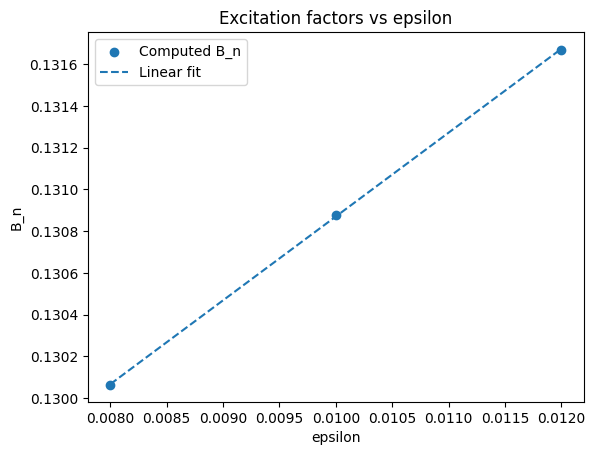

In [194]:
plt.scatter(epsilon_list_2_selected, B_n_list, label="Computed B_n")
plt.plot(epsilon_list_2_selected, [k2*eps + b2 for eps in epsilon_list_2_selected], label="Linear fit", linestyle="--")
plt.xlabel("epsilon")
plt.ylabel("B_n")
plt.title("Excitation factors vs epsilon")
plt.legend()   

### l=3

In [180]:
l=3
set_parameters(l_value=l)

result_list_3 = calculate_Bn_list(
    omega_list=omega_qnm_list_epsilon_3_selected,
    epsilon_list=epsilon_list_3_selected,
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    steps_per_period=150,
    verbose=True,
)

B_n_list_3 = [item["B_n"] for item in result_list_3]


Calculating B_n for omega_n = (0.6011549003740739-0.09341409606218931j) epsilon = 0.005
PL_initial = (-0.09341409526739512-0.6011549039192822j)
boundary condition= + P_R = (0.09341409226536197+0.6011548759735867j)
boundary condition= - P_R = (-0.09341409226536197-0.6011548759735867j)
beta = 0.15415816086830103
r_min = (1.9968749958329963-2.6694472810814833e-10j)
r_max = (19746.02036986729+3070.6573833601346j)
r_m_check_left = (2.9999999813161216+5.858021368389341e-09j)
r_m_check_right = (3.000000005391478+5.2315469126901215e-09j)
x_m = (1.6215985886097528+0j)
x_max = (19764.444475971803+3070.9659583231182j)
P_L,-(rho_m) = (0.034234010945844065-0.04333270747678381j)
Omega_L,-(rho_m) = (-1.8811452106308253-1.7488165452123878j)
Ptilde_R,+(rho_m) = (-2.612322298310496+0.21303079265994856j)
Ptilde_R,-(rho_m) = (1.040206790900852+0.5689265472464459j)
P_R,+(rho_m) = (0.034232619836933244-0.04333477990089829j)
P_R,-(rho_m) = (-0.27699266866263006-0.24490733282639252j)
phi_R,+(rho_m) = (0.02577

In [183]:
k3, b3 = np.polyfit(epsilon_list_3_selected, B_n_list_3, 1)

print("k3 =", k3)
print("b3 =", b3)
print(B_n_list_3)

k3 = (-0.19447909760500887-0.27917328043011735j)
b3 = (-0.09397128436810372-0.04911540174850417j)
[np.complex128(-0.09492104781623266-0.050532246830171816j), np.complex128(-0.09594436539402401-0.051880911203409104j), np.complex128(-0.09979999928627996-0.057495844831287j)]


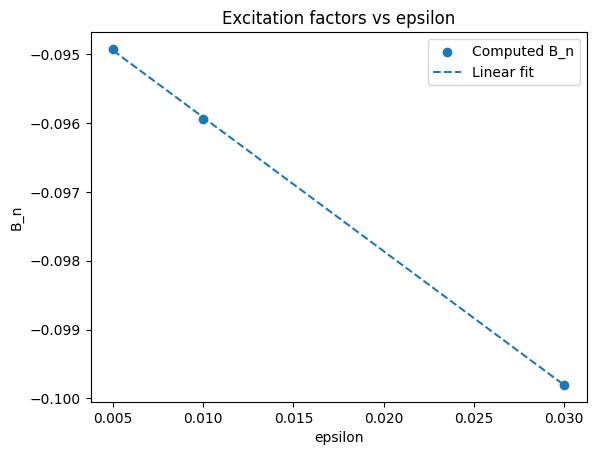

In [192]:
plt.scatter(epsilon_list_3_selected, B_n_list_3, label="Computed B_n")
plt.plot(epsilon_list_3_selected, [k3*eps + b3 for eps in epsilon_list_3_selected], label="Linear fit", linestyle="--")
plt.xlabel("epsilon")
plt.ylabel("B_n")
plt.title("Excitation factors vs epsilon")
plt.legend()   

### l=4

In [188]:
l=4
set_parameters(l_value=l)

result_list_4 = calculate_Bn_list(
    omega_list=omega_qnm_list_epsilon_4_selected,
    epsilon_list=epsilon_list_4_selected,
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    steps_per_period=150,
    verbose=True,
)

B_n_list_4 = [item["B_n"] for item in result_list_4]

Calculating B_n for omega_n = (0.8114003681888884-0.09489107286337288j) epsilon = 0.005
PL_initial = (-0.09489106913568891-0.8114003709596446j)
boundary condition= + P_R = (0.09489106929835751+0.8114003377468376j)
boundary condition= - P_R = (-0.09489106929835751-0.8114003377468376j)
beta = 0.11641847137747574
r_min = (1.9968749974096223-2.7399212758658957e-09j)
r_max = (19847.817901819097+2322.8804584877003j)
r_m_check_left = (3.0000000095802473-1.0688687799410108e-08j)
r_m_check_right = (3.0000000062757737+4.128066789441109e-09j)
x_m = (1.6215985886097528+0j)
x_max = (19866.242000395472+2323.113491011246j)
P_L,-(rho_m) = (0.036501192296403036-0.031359088499421296j)
Omega_L,-(rho_m) = (-2.3202166089760032-2.0839739469903824j)
Ptilde_R,+(rho_m) = (-2.9355493657342864+0.18677045711433155j)
Ptilde_R,-(rho_m) = (0.6402211868921164+0.5236232276596737j)
P_R,+(rho_m) = (0.03660922938378121-0.031392779999164976j)
P_R,-(rho_m) = (-0.3203028134927729-0.29451957385123145j)
phi_R,+(rho_m) = (0.02

In [189]:
k4, b4 = np.polyfit(epsilon_list_4_selected, B_n_list_4, 1)

print("k4 =", k4)
print("b4 =", b4)
print(B_n_list_4)

k4 = (0.06855222108286692+0.27425888033097706j)
b4 = (0.06538075441304447+0.06529741461548498j)
[np.complex128(0.0657116457084219+0.0666609922159055j), np.complex128(0.06678147335979412+0.07080188422519046j), np.complex128(0.0674195163304751+0.07351360582356273j)]


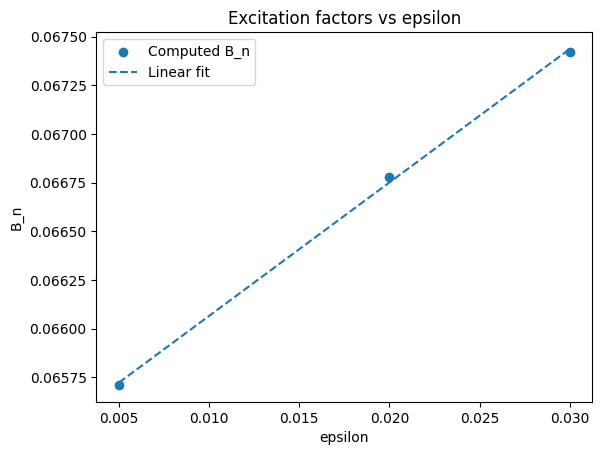

In [191]:
plt.scatter(epsilon_list_4_selected, B_n_list_4, label="Computed B_n")
plt.plot(epsilon_list_4_selected, [k4*eps + b4 for eps in epsilon_list_4_selected], label="Linear fit", linestyle="--")
plt.xlabel("epsilon")
plt.ylabel("B_n")
plt.title("Excitation factors vs epsilon")
plt.legend()   

So one can see that the discrepencies between PLminus and PRplus are small. So we can take these results as accurate ones.

# RK QNM and Excitation factors

In short: delta_Omega are non-zero for RK with l=2,3,4. Meanwhile, the resonant condition is also satisfied. So it means this method does give some non-vanishing RK discrepancies in omega.

In [4]:
# import RK

try:
    import QNM_phase_amplitude.qnm_functions_my_RK_potential as qnm_functions_my_RK_potential
except ModuleNotFoundError:
    import qnm_functions_my_RK_potential as qnm_functions_my_RK_potential
_
importlib.reload(qnm_functions_my_RK_potential)
globals().update({name: getattr(qnm_functions_my_RK_potential, name) for name in qnm_functions_my_RK_potential.__all__})

# QNM frequencies

### l=2

In [5]:
# Try epsilon=0.01, l=2
l=2
set_parameters(l_value=l)
omega_qnm_2_RK, ratio, zeta = find_QNM_muller(
    omega_ini=omega_qnm_2,
    epsilon=0.01,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.37367139964832247-0.08896227650215158j) A_in/A_out(z0) = (-0.010437148720526911+0.002815835071516842j) |A_in/A_out(z0)| = 0.010810319170328913
z1 = (0.37377139964832246-0.08896227650215158j) A_in/A_out(z1) = (-0.009470512816432535+0.0029399772961402264j) |A_in/A_out(z1)| = 0.009916354143939843
z2 = (0.37367139964832247-0.08886227650215157j) A_in/A_out(z2) = (-0.010536336801993647+0.0038366495754714827j) |A_in/A_out(z2)| = 0.011213129499386477

Muller iteration 1
z0 = (0.37377139964832246-0.08896227650215158j) A_in/A_out(z0) = (-0.009470512816432535+0.0029399772961402264j) |A_in/A_out(z0)| = 0.009916354143939843
z1 = (0.37367139964832247-0.08886227650215157j) A_in/A_out(z1) = (-0.010536336801993647+0.0038366495754714827j) |A_in/A_out(z1)| = 0.011213129499386477
z2 = (0.374149681752986-0.0897404827583116j) A_in/A_out(z2) = (-0.004992272157353247-0.004654622034410596j) |A_in/A_out(z2)| = 0.006825561337817211
|delta z| = 0.001

Muller iteration 2
z0 = (0.37367139

In [206]:
(omega_qnm_2_RK-omega_qnm_2)/0.01

# actually, if one try different values of epsilon, they all give a similar delta_Omega value for RK l=2.

(0.1032008283019803-0.03682347872265568j)

### l=3

In [6]:
# Try epsilon=0.01 for l=3
l=3
set_parameters(l_value=l)
omega_qnm_3_RK, ratio, zeta = find_QNM_muller(
    omega_ini=omega_qnm_3,
    epsilon=0.01,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.5994435277105972-0.0927032103194887j) A_in/A_out(z0) = (0.002382655022867482-0.0032119021449066518j) |A_in/A_out(z0)| = 0.003999169957185064
z1 = (0.5995435277105972-0.0927032103194887j) A_in/A_out(z1) = (0.0016480482202165826-0.0029655639687903184j) |A_in/A_out(z1)| = 0.003392732319111903
z2 = (0.5994435277105972-0.09260321031948869j) A_in/A_out(z2) = (0.0021464073051622487-0.003937597511945535j) |A_in/A_out(z2)| = 0.004484611297061712

Muller iteration 1
z0 = (0.5995435277105972-0.0927032103194887j) A_in/A_out(z0) = (0.0016480482202165826-0.0029655639687903184j) |A_in/A_out(z0)| = 0.003392732319111903
z1 = (0.5994435277105972-0.09260321031948869j) A_in/A_out(z1) = (0.0021464073051622487-0.003937597511945535j) |A_in/A_out(z1)| = 0.004484611297061712
z2 = (0.5998543373594605-0.09297672790859589j) A_in/A_out(z2) = (2.6544506578213953e-05-0.00021196641539858305j) |A_in/A_out(z2)| = 0.00021362203090132234
|delta z| = 0.0005552296434554643

Muller iteration 2
z0 

In [7]:
(omega_qnm_3_RK-omega_qnm_3)/0.01

# the delta_Omega for l=3 is 1e-2

(0.04227427600770328-0.029850204306305916j)

In [211]:
# Try epsilon=0.005 for l=3
l=3
set_parameters(l_value=l)
omega_qnm_3_RK005, ratio, zeta = find_QNM_muller(
    omega_ini=omega_qnm_3,
    epsilon=0.005,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.5994435277105972-0.0927032103194887j) A_in/A_out(z0) = (0.0011910696631697952-0.0016181658606338081j) |A_in/A_out(z0)| = 0.00200925550765555
z1 = (0.5995435277105972-0.0927032103194887j) A_in/A_out(z1) = (0.0004512511286409619-0.0013734495149376887j) |A_in/A_out(z1)| = 0.001445680169049266
z2 = (0.5994435277105972-0.09260321031948869j) A_in/A_out(z2) = (0.000940114977861281-0.0023468371931425697j) |A_in/A_out(z2)| = 0.0025281338933522512

Muller iteration 1
z0 = (0.5995435277105972-0.0927032103194887j) A_in/A_out(z0) = (0.0004512511286409619-0.0013734495149376887j) |A_in/A_out(z0)| = 0.001445680169049266
z1 = (0.5994435277105972-0.09260321031948869j) A_in/A_out(z1) = (0.000940114977861281-0.0023468371931425697j) |A_in/A_out(z1)| = 0.0025281338933522512
z2 = (0.5996484962285396-0.09285250952806844j) A_in/A_out(z2) = (4.6933527114079374e-05-8.89314257453984e-06j) |A_in/A_out(z2)| = 4.7768650307697795e-05
|delta z| = 0.00032274167494452446

Muller iteration 2
z0

In [212]:
(omega_qnm_3_RK005-omega_qnm_3)/0.005

# the delta_Omega for l=3 is 1e-2

(0.04219841912385114-0.029689498121684976j)

### l=4

In [8]:
# Try epsilon=0.01 for l=4
l=4
set_parameters(l_value=l)
omega_qnm_4_RK, ratio, zeta = find_QNM_muller(
    omega_ini=omega_qnm_4,
    epsilon=0.01,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.8091803585360554-0.09416428274127403j) A_in/A_out(z0) = (-0.0002565291920088961+0.0026032598204203694j) |A_in/A_out(z0)| = 0.0026158686738763912
z1 = (0.8092803585360554-0.09416428274127403j) A_in/A_out(z1) = (0.0002845470878295177+0.0022345721384054904j) |A_in/A_out(z1)| = 0.00225261618722106
z2 = (0.8091803585360554-0.09406428274127403j) A_in/A_out(z2) = (0.00015484685921383177+0.0031615005973277192j) |A_in/A_out(z2)| = 0.003165290441130468

Muller iteration 1
z0 = (0.8092803585360554-0.09416428274127403j) A_in/A_out(z0) = (0.0002845470878295177+0.0022345721384054904j) |A_in/A_out(z0)| = 0.00225261618722106
z1 = (0.8091803585360554-0.09406428274127403j) A_in/A_out(z1) = (0.00015484685921383177+0.0031615005973277192j) |A_in/A_out(z1)| = 0.003165290441130468
z2 = (0.809390309774098-0.09454097553452763j) A_in/A_out(z2) = (-0.0006476501531701865-0.00013346716426101577j) |A_in/A_out(z2)| = 0.0006612595593541488
|delta z| = 0.0005208795844487845

Muller iteration

In [210]:
(omega_qnm_4_RK-omega_qnm_4)/0.01

# the delta_Omega for l=4 is 1e-2

(0.026987956247181977-0.02945186281713974j)

In [9]:
# Try epsilon=0.005 for l=4
l=4
set_parameters(l_value=l)
omega_qnm_4_RK005, ratio, zeta = find_QNM_muller(
    omega_ini=omega_qnm_4,
    epsilon=0.005,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.8091803585360554-0.09416428274127403j) A_in/A_out(z0) = (-0.00011381286987604031+0.0013131004191467852j) |A_in/A_out(z0)| = 0.0013180235506670141
z1 = (0.8092803585360554-0.09416428274127403j) A_in/A_out(z1) = (-0.00037703594813737494+0.0008763098075480325j) |A_in/A_out(z1)| = 0.0009539785034227548
z2 = (0.8091803585360554-0.09406428274127403j) A_in/A_out(z2) = (3.2373461102427466e+99-9.461479279821742e+99j) |A_in/A_out(z2)| = 1e+100

Muller iteration 1
z0 = (0.8092803585360554-0.09416428274127403j) A_in/A_out(z0) = (-0.00037703594813737494+0.0008763098075480325j) |A_in/A_out(z0)| = 0.0009539785034227548
z1 = (0.8091803585360554-0.09406428274127403j) A_in/A_out(z1) = (3.2373461102427466e+99-9.461479279821742e+99j) |A_in/A_out(z1)| = 1e+100
z2 = (0.8091803585360554-0.09416428274127403j) A_in/A_out(z2) = (-0.00011381286987604031+0.0013131004191467852j) |A_in/A_out(z2)| = 0.0013180235506670141
|delta z| = 0.00010000000000000286

Muller iteration 2
z0 = (0.809180

In [10]:
(omega_qnm_4_RK005-omega_qnm_4)/0.005

# this delta_Omega for l=4 is 1e-3.

(0.001368778535870696+0.00045741333803972495j)

In [216]:
# Try epsilon=0.015 for l=4
l=4
set_parameters(l_value=l)
omega_qnm_4_RK015, ratio, zeta = find_QNM_muller(
    omega_ini=omega_qnm_4,
    epsilon=0.015,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.8091803585360554-0.09416428274127403j) A_in/A_out(z0) = (-0.00041869515098096874+0.003955110229512048j) |A_in/A_out(z0)| = 0.003977210398890888
z1 = (0.8092803585360554-0.09416428274127403j) A_in/A_out(z1) = (0.0001246464588163714+0.003560624392790962j) |A_in/A_out(z1)| = 0.0035628054684803474
z2 = (0.8091803585360554-0.09406428274127403j) A_in/A_out(z2) = (-0.0001973612400803989+0.004556480906895289j) |A_in/A_out(z2)| = 0.004560753195908257

Muller iteration 1
z0 = (0.8092803585360554-0.09416428274127403j) A_in/A_out(z0) = (0.0001246464588163714+0.003560624392790962j) |A_in/A_out(z0)| = 0.0035628054684803474
z1 = (0.8091803585360554-0.09406428274127403j) A_in/A_out(z1) = (-0.0001973612400803989+0.004556480906895289j) |A_in/A_out(z1)| = 0.004560753195908257
z2 = (0.809556683150384-0.09434207635328636j) A_in/A_out(z2) = (0.0008890691988457826+0.0015080533030576773j) |A_in/A_out(z2)| = 0.0017506195489595826
|delta z| = 0.0004677494053704224

Muller iteration 2


In [217]:
(omega_qnm_4_RK015-omega_qnm_4)/0.015

# the delta_Omega for l=4 is 1e-3.

(0.026905941892992523-0.02861498807908055j)

Note that the 0.005 result is different from 0.01, 0.015 results for l=4. We'll see this later.

## Excitation factors \& Checking resonantion conditions

In [11]:
# Check resonant condition of RK

l=2
set_parameters(l_value=l)

list2=calculate_Bn(
    omega_n=omega_qnm_2_RK,
    epsilon=0.01,
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    label_R_plus="+",
    label_R_minus="-",
    domega_step=1e-6,
    steps_per_period=150,
    verbose=True
)

PL_initial = (-0.08868196145018509-0.37757933850307396j)
boundary condition= + P_R = (0.08933050676151977+0.3747033889649284j)
boundary condition= - P_R = (-0.08933050676151977-0.3747033889649284j)
beta = 0.23403465095097328
r_min = (1.9937499997035875+5.499464019856914e-09j)
r_max = (19437.973321694157+4637.612767088778j)
r_m_check_left = (3.0000000189560563+2.0124513240094358e-08j)
r_m_check_right = (3.0000000029073823+6.8510746069339046e-09j)
x_m = (1.6294764085221036+0j)
x_max = (19456.402734607254+4638.081227412412j)
P_L,-(rho_m) = (0.026631126238270447-0.06811427723281074j)
Omega_L,-(rho_m) = (-1.2636093331903755-1.3085521932143491j)
Ptilde_R,+(rho_m) = (-2.2918402083436256+0.3009163994712807j)
Ptilde_R,-(rho_m) = (1.5071385512553426+0.637804399110296j)
P_R,+(rho_m) = (0.026632311260964332-0.06811229062603194j)
P_R,-(rho_m) = (-0.21961231295121933-0.17744539344416624j)
phi_R,+(rho_m) = (0.026156840890723086-7701.225045921792j)
phi_R,-(rho_m) = (1.024472697992894+7702.143952607875

In [12]:
# Check resonant condition of RK

l=3
set_parameters(l_value=l)

list3=calculate_Bn(
    omega_n=omega_qnm_3_RK,
    epsilon=0.01,
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    label_R_plus="+",
    label_R_minus="-",
    domega_step=1e-6,
    steps_per_period=150,
    verbose=True
)

PL_initial = (-0.09213358478721734-0.6056055387453059j)
boundary condition= + P_R = (0.09300170856582218+0.5998662460151496j)
boundary condition= - P_R = (-0.09300170856582218-0.5998662460151496j)
beta = 0.15381283131616022
r_min = (1.9937499959707383-2.5795677368958576e-10j)
r_max = (19747.08228065401+3063.833204888492j)
r_m_check_left = (3.0000000136702-6.6870876726048654e-09j)
r_m_check_right = (3.0000000053486837+5.173093607993562e-09j)
x_m = (1.6294764085221036+0j)
x_max = (19765.511670686665+3064.1410885752953j)
P_L,-(rho_m) = (0.03324730053671124-0.043768790568735734j)
Omega_L,-(rho_m) = (-1.8820969587350214-1.7504641723560581j)
Ptilde_R,+(rho_m) = (-2.6136011748994554+0.21422151625242253j)
Ptilde_R,-(rho_m) = (1.0364804222402841+0.5678336120966913j)
P_R,+(rho_m) = (0.03324852375612176-0.0437701928353681j)
P_R,-(rho_m) = (-0.27580417446951805-0.24363637090656204j)
phi_R,+(rho_m) = (0.03007569990528843-12136.760541457728j)
phi_R,-(rho_m) = (1.1634379847985479+12137.603468601099j)

In [ ]:
# Check resonant condition of RK

l=4
set_parameters(l_value=l)

list4=calculate_Bn(
    omega_n=omega_qnm_4_RK,
    epsilon=0.01,
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    label_R_plus="+",
    label_R_minus="-",
    domega_step=1e-6,
    steps_per_period=150,
    verbose=True
)

PL_initial = (-0.09352656454017534-0.8175837795571759j)
boundary condition= + P_R = (0.09445879780334451+0.8094502075813651j)
boundary condition= - P_R = (-0.09445879780334451-0.8094502075813651j)
beta = 0.11616958676380969
r_min = (1.993749997493955-2.6493950410559484e-09j)
r_max = (19848.398067629318+2317.9368864305993j)
r_m_check_left = (3.0000000204571045-3.272851085709739e-08j)
r_m_check_right = (3.000000006223464+4.081187823454235e-09j)
x_m = (1.6294764085221036+0j)
x_max = (19866.82745017057+2318.169420737012j)
P_L,-(rho_m) = (0.035363514292370654-0.032771387759983533j)
Omega_L,-(rho_m) = (-2.3120200558611437-2.089516480663293j)
Ptilde_R,+(rho_m) = (-2.9375568208175564+0.18876670299901152j)
Ptilde_R,-(rho_m) = (0.63624121522742+0.5224435022995828j)
P_R,+(rho_m) = (0.03536035146337436-0.03277218140272577j)
P_R,-(rho_m) = (-0.3190028404527946-0.2927976033496392j)
phi_R,+(rho_m) = (0.03177989862965495-16293.886439600234j)
phi_R,-(rho_m) = (1.2787791612587875+16294.708025065962j)
Om

In [ ]:
# Check resonant condition of RK

l=4
set_parameters(l_value=l)

list4=calculate_Bn(
    omega_n=omega_qnm_4_RK005,
    epsilon=0.005,
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    label_R_plus="+",
    label_R_minus="-",
    domega_step=1e-6,
    steps_per_period=150,
    verbose=True
)

PL_initial = (-0.09369393051140597-0.813245671638634j)
boundary condition= + P_R = (0.09416199211710556+0.8091871718993319j)
boundary condition= - P_R = (-0.09416199211710556-0.8091871718993319j)
beta = 0.11584513089245116
r_min = (1.9968749974444717-2.7656245349202245e-09j)
r_max = (19849.146571917976+2311.492033830403j)
r_m_check_left = (3.0000000116702177-1.5317258756367613e-08j)
r_m_check_right = (3.000000006288555+4.109912838876073e-09j)
x_m = (1.6215985886097528+0j)
x_max = (19867.57067039612+2311.723918713096j)
P_L,-(rho_m) = (0.03533478645167945-0.03315551441313165j)
Omega_L,-(rho_m) = (-2.308480536882318-2.0968159474567276j)
Ptilde_R,+(rho_m) = (-2.928994209590002+0.1881000294491373j)
Ptilde_R,-(rho_m) = (0.6429593193404509+0.5204418858642074j)
P_R,+(rho_m) = (0.03387951747036848-0.03303069933244991j)
P_R,-(rho_m) = (-0.318829009125462-0.29216052594073094j)
phi_R,+(rho_m) = (0.035382642122234506-16287.970705979731j)
phi_R,-(rho_m) = (1.2790630570271835+16288.792029065153j)
Ome

So for l=4, epsilon=0.005, the resonant condition is not satisfied very well, and this value should be discarded.

But in general, for l=2,3,4, the resonant conditions are satisfied. So delta_Omega of RK indeed has a non-zero value using this method

# R3 with my potential

In short, the conclusion is: though delta_Omega are slightly different from that obtained using the potential given in arXiv:2404.11110v2, the resonant condition is satisfied.

In [ ]:
# import R3 of my potential

try:
    import QNM_phase_amplitude.qnm_functions_my_R3_potential as qnm_functions_my_R3_potential
except ModuleNotFoundError:
    import qnm_functions_my_R3_potential as qnm_functions_my_R3_potential
_
importlib.reload(qnm_functions_my_R3_potential)
globals().update({name: getattr(qnm_functions_my_R3_potential, name) for name in qnm_functions_my_R3_potential.__all__})

### l=2

In [228]:
# Try five epsilon values to find delta_Omega, with linear fit
l=2
set_parameters(l_value=l)
epsilon_list_2_mine=[0.005, 0.008, 0.01, 0.012, 0.015]
omega_qnm_list_epsilon_2_mine=find_QNM_list_muller(
    epsilon_list,
    omega_qnm_2,
    delta=None,
    tol=1e-10,
    max_iter=50,
    n_steps_min=20000,
    n_steps_max=50000,
    qnm_cutoff=100,
    verbose=False,
    use_previous_as_initial=True
)

Finding QNM for epsilon = 0.005
Muller found omega_qnm = (0.37494167901785497-0.089749264397488j)
A_in/A_out_qnm = (9.157464206037335e-88-1.0375828110880867e-87j)
zeta = (-4.4563449049329256e+26-2.8053884664022673e+25j)
|A_in/A_out_qnm| = 1.3838965267367378e-87
omega_qnm = (0.37494167901785497-0.089749264397488j)
A_in/A_out = (9.157464206037335e-88-1.0375828110880867e-87j)
zeta = (-4.4563449049329256e+26-2.8053884664022673e+25j)

Finding QNM for epsilon = 0.015
Muller found omega_qnm = (0.37772369383275306-0.0910014272877989j)
A_in/A_out_qnm = (9.947188991360374e-88+9.62135078050684e-88j)
zeta = (-2.8336843682224866e+27-3.688894000570142e+27j)
|A_in/A_out_qnm| = 1.3838965267367376e-87
omega_qnm = (0.37772369383275306-0.0910014272877989j)
A_in/A_out = (9.947188991360374e-88+9.62135078050684e-88j)
zeta = (-2.8336843682224866e+27-3.688894000570142e+27j)



In [232]:
epsilon_list_2_mine=[0.005, 0.008, 0.01, 0.012, 0.015]
omega_qnm_list_epsilon_2_mine=[0.37494167901785497-0.089749264397488j,0.3758721420890516-0.0901847895667071j,0.3764123826179138-0.0904766118906654j,0.37698465714552504-0.09076240185109782j,(0.37772369383275306-0.0910014272877989j)]

In [233]:
# two methods to select points. This selects the points that gives the linear fit b closest to omega_qnm_2
result = select_qnm_linear_fit_subset(
    epsilon_list_2_mine,
    omega_qnm_list_epsilon_2_mine,
    omega_qnm_2,
    min_points=3,
    subset_mode="all",        # or "contiguous"
)

print("selected indices =", result["selected_indices"])
print("selected epsilons =", result["epsilon_selected"])
print("selected omegas =", result["omega_selected"])

print("final k (with b fixed to omega_qnm_2) =", result["k"])
print("free-fit b =", result["b_free"])
print("|b_free - omega_qnm_2| =", result["intercept_error"])
print("RMSE with fixed intercept =", result["rmse_fixed"])

selected indices = [1, 2, 3]
selected epsilons = [0.008, 0.01, 0.012]
selected omegas = [(0.3758721420890516-0.0901847895667071j), (0.3764123826179138-0.0904766118906654j), (0.37698465714552504-0.09076240185109782j)]
final k (with b fixed to omega_qnm_2) = (0.275243049312265-0.15105507334070578j)
free-fit b = (0.3736417729763131-0.08903057039184654j)
|b_free - omega_qnm_2| = 7.444323383637705e-05
RMSE with fixed intercept = 1.4246901429970567e-05


In [234]:
# This selects the points that gives the lowest variance of delta_Omega
result = select_qnm_low_variance_subset(
    epsilon_list_2_mine,
    omega_qnm_list_epsilon_2_mine,
    omega_qnm_2,
    min_points=3,
    min_relative_variance_reduction=0.05,
    min_sigma_distance=1.5,
)

print("selected indices =", result["selected_indices"])
print("removed indices =", result["removed_indices"])
print("selected epsilons =", result["epsilon_selected"])
print("selected omegas =", result["omega_selected"])
print("delta_Omega =", result["k"])
print("delta_Omega std =", result["delta_omega_std"])

selected indices = [1, 2, 3]
removed indices = [0, 4]
selected epsilons = [0.008, 0.01, 0.012]
selected omegas = [(0.3758721420890516-0.0901847895667071j), (0.3764123826179138-0.0904766118906654j), (0.37698465714552504-0.09076240185109782j)]
delta_Omega = (0.275243049312265-0.15105507334070578j)
delta_Omega std = 0.0014075621103676295


In [235]:
for step in result["removal_history"]:
    print(
        "removed epsilon =", step["epsilon_removed"],
        "relative variance reduction =", step["relative_variance_reduction"],
        "sigma distance =", step["sigma_distance"],
    )

removed epsilon = 0.005 relative variance reduction = 0.5718342429767179 sigma distance = 1.6216872625526493
removed epsilon = 0.015 relative variance reduction = 0.9611367431144885 sigma distance = 1.7066217132122745


So for my R3 potential, l=2, delta_Omega= 0.275243049312265 - 0.15105507334070578j

Then, check if they satisfies the resonant condition

In [236]:
l=2
set_parameters(l_value=l)

result_list_2 = calculate_Bn_list(
    omega_list=omega_qnm_list_epsilon_2_mine[1:4],
    epsilon_list=epsilon_list_2_mine[1:4],
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    steps_per_period=150,
    verbose=True,
)

B_n_list_mine = [item["B_n"] for item in result_list_2]

Calculating B_n for omega_n = (0.3758721420890516-0.0901847895667071j) epsilon = 0.008
PL_initial = (-0.08969978734380452-0.3776645209068903j)
boundary condition= + P_R = (0.09018478502708059+0.37587212319473184j)
boundary condition= - P_R = (-0.09018478502708059-0.37587212319473184j)
beta = 0.2354832863379803
r_min = (1.9949999998327588+5.614353687353851e-09j)
r_max = (19431.23298529835+4665.787863929057j)
r_m_check_left = (3.0000000103225517+3.676132113455033e-08j)
r_m_check_right = (3.000000002868343+6.897985550813335e-09j)
x_m = (1.6263270921608803+0j)
x_max = (19449.660285697046+4666.259223934231j)
P_L,-(rho_m) = (0.02975181853096809-0.07136860788969297j)
Omega_L,-(rho_m) = (-1.2562986835308458-1.3081364225978946j)
Ptilde_R,+(rho_m) = (-2.3025442859433225+0.30734849504661554j)
Ptilde_R,-(rho_m) = (1.5126327074781194+0.6442671664620553j)
P_R,+(rho_m) = (0.02975307858395201-0.07137011565792238j)
P_R,-(rho_m) = (-0.22229446458987553-0.18046946170957315j)
phi_R,+(rho_m) = (0.010455582

All these three values satisfy the resonant condition.

### l=3

In [239]:
# Try epsilon=0.01
l=3
set_parameters(l_value=l)
omega_qnm_3_epsilon_mine, ratio, zeta = find_QNM_muller(
    omega_ini=omega_qnm_3,
    epsilon=0.01,
    delta=1e-4,
    r_m=3*M,
    rho_max=10**4*M,
    n_steps_min=80000,
    n_steps_max=None,          # let code choose automatically according to points per period and rho_max
    points_per_period=150,     # increase for higher l
    qnm_cutoff=150,
    tol=1e-7,
    max_iter=50,
    max_step=1e-3,
    verbose=True,
    print_termination=False
)

Muller iteration 0
z0 = (0.5994435277105972-0.0927032103194887j) A_in/A_out(z0) = (0.020542049554362146-0.018772642200490432j) |A_in/A_out(z0)| = 0.027827825913669654
z1 = (0.5995435277105972-0.0927032103194887j) A_in/A_out(z1) = (0.019832272793315613-0.01858407856015966j) |A_in/A_out(z1)| = 0.027178797252245594
z2 = (0.5994435277105972-0.09260321031948869j) A_in/A_out(z2) = (0.020353424143707742-0.019477832718669794j) |A_in/A_out(z2)| = 0.028171756100572588

Muller iteration 1
z0 = (0.5995435277105972-0.0927032103194887j) A_in/A_out(z0) = (0.019832272793315613-0.01858407856015966j) |A_in/A_out(z0)| = 0.027178797252245594
z1 = (0.5994435277105972-0.09260321031948869j) A_in/A_out(z1) = (0.020353424143707742-0.019477832718669794j) |A_in/A_out(z1)| = 0.028171756100572588
z2 = (0.6002868626007126-0.09314059869218935j) A_in/A_out(z2) = (0.015429137096948986-0.014045932888501063j) |A_in/A_out(z2)| = 0.02086495871706252
|delta z| = 0.001

Muller iteration 2
z0 = (0.5994435277105972-0.09260321

In [240]:
(omega_qnm_3_epsilon_mine-omega_qnm_3)/0.01

(0.3404740615747026-0.16061204468665602j)

In [241]:
# Check resonant condition

l=3
set_parameters(l_value=l)

list3=calculate_Bn(
    omega_n=omega_qnm_3_epsilon_mine,
    epsilon=0.01,
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    label_R_plus="+",
    label_R_minus="-",
    domega_step=1e-6,
    steps_per_period=150,
    verbose=True
)

PL_initial = (-0.09350547141870329-0.607858842113742j)
boundary condition= + P_R = (0.09430932695586522+0.6028482440021833j)
boundary condition= - P_R = (-0.09430932695586522-0.6028482440021833j)
beta = 0.15518179985989886
r_min = (1.9937499959481073-1.490187991400052e-10j)
r_max = (19742.869049394292+3090.883718029963j)
r_m_check_left = (3.000000107601124-1.3886246621501387e-08j)
r_m_check_right = (3.0000000053132756+5.209705618292038e-09j)
x_m = (1.6294764085221036+0j)
x_max = (19761.298439738406+3091.1943419360855j)
P_L,-(rho_m) = (0.03774462867706269-0.04338718116826669j)
Omega_L,-(rho_m) = (-1.8862719621072193-1.7142457931484731j)
Ptilde_R,+(rho_m) = (-2.62536559968146+0.21412542751765834j)
Ptilde_R,-(rho_m) = (1.0348902570009042+0.5742935745596581j)
P_R,+(rho_m) = (0.03774333208537171-0.04338812232276969j)
P_R,-(rho_m) = (-0.27894607134909355-0.24752855427966136j)
phi_R,+(rho_m) = (0.013770764961320285-12199.731144667667j)
phi_R,-(rho_m) = (1.1614613005602303+12200.574183631434j)

### l=4

In [249]:
#try 0.02, 0.03
l=4
set_parameters(l_value=l)
epsilon_list_4_mine=[0.005,0.01,0.015,0.02, 0.03]
omega_qnm_list_epsilon_4_mine=find_QNM_list_muller(
    epsilon_list_4_mine,
    omega_qnm_4,
    delta=1e-4,
    tol=1e-7,
    rho_max=10**4*M,
    max_iter=50,
    n_steps_min=20000,
    n_steps_max=None,
    points_per_period=150,
    qnm_cutoff=150,
    verbose=True,
    use_previous_as_initial=True
)

Finding QNM for epsilon = 0.005
Muller iteration 0
z0 = (0.8091803585360554-0.09416428274127403j) A_in/A_out(z0) = (-0.007866074423830104+0.012707050335990932j) |A_in/A_out(z0)| = 0.01494470659071771
z1 = (0.8092803585360554-0.09416428274127403j) A_in/A_out(z1) = (-0.007342908631239463+0.01232967337306367j) |A_in/A_out(z1)| = 0.014350580220087488
z2 = (0.8091803585360554-0.09406428274127403j) A_in/A_out(z2) = (-0.007517348648802577+0.013236032304144546j) |A_in/A_out(z2)| = 0.015221796275867441

Muller iteration 1
z0 = (0.8092803585360554-0.09416428274127403j) A_in/A_out(z0) = (-0.007342908631239463+0.01232967337306367j) |A_in/A_out(z0)| = 0.014350580220087488
z1 = (0.8091803585360554-0.09406428274127403j) A_in/A_out(z1) = (-0.007517348648802577+0.013236032304144546j) |A_in/A_out(z1)| = 0.015221796275867441
z2 = (0.8107637966656739-0.09449285363191522j) A_in/A_out(z2) = (-0.0008960751099376041+0.0049001958112610275j) |A_in/A_out(z2)| = 0.004981452558375901
|delta z| = 0.0016404113260504

In [ ]:
for i in range (0, len(epsilon_list_4_mine)):
    print((omega_qnm_list_epsilon_4_mine[i]-omega_qnm_4)/epsilon_list_4_mine[i])

(0.43682225897081484-0.16554535465840847j)
(0.4299658740699708-0.1652786649159424j)
(0.42789000263364263-0.1649083999074134j)
(0.4269636736965676-0.16306882176694085j)
(0.42524996426857775-0.16169973515582176j)


In [252]:
# two methods to select points. This selects the points that gives the linear fit b closest to omega_qnm_2
result = select_qnm_linear_fit_subset(
    epsilon_list_4_mine,
    omega_qnm_list_epsilon_4_mine,
    omega_qnm_4,
    min_points=3,
    subset_mode="all",        # or "contiguous"
)

print("selected indices =", result["selected_indices"])
print("selected epsilons =", result["epsilon_selected"])
print("selected omegas =", result["omega_selected"])

print("final k (with b fixed to omega_qnm_2) =", result["k"])
print("free-fit b =", result["b_free"])
print("|b_free - omega_qnm_2| =", result["intercept_error"])
print("RMSE with fixed intercept =", result["rmse_fixed"])

selected indices = [0, 1, 2]
selected epsilons = [0.005, 0.01, 0.015]
selected omegas = [(0.8113644698309095-0.09499200951456607j), (0.8134800172767551-0.09581706939043345j), (0.81559870857556-0.09663790873988523j)]
final k (with b fixed to omega_qnm_2) = (0.42912112706810585-0.1650596866777785j)
free-fit b = (0.8092468264830914-0.09416976332297582j)
|b_free - omega_qnm_2| = 6.669351361993958e-05
RMSE with fixed intercept = 2.523828067546015e-05


In [253]:
# This selects the points that gives the lowest variance of delta_Omega
result = select_qnm_low_variance_subset(
    epsilon_list_4_mine,
    omega_qnm_list_epsilon_4_mine,
    omega_qnm_4,
    min_points=3,
    min_relative_variance_reduction=0.05,
    min_sigma_distance=1.5,
)

print("selected indices =", result["selected_indices"])
print("removed indices =", result["removed_indices"])
print("selected epsilons =", result["epsilon_selected"])
print("selected omegas =", result["omega_selected"])
print("delta_Omega =", result["k"])
print("delta_Omega std =", result["delta_omega_std"])

selected indices = [1, 2, 3]
removed indices = [0, 4]
selected epsilons = [0.01, 0.015, 0.02]
selected omegas = [(0.8134800172767551-0.09581706939043345j), (0.81559870857556-0.09663790873988523j), (0.8177196320099868-0.09742565917661285j)]
delta_Omega = (0.42766525169406033-0.1639445312793636j)
delta_Omega std = 0.0015841256002575525


In [254]:
l=4
set_parameters(l_value=l)

result_list_4 = calculate_Bn_list(
    omega_list=omega_qnm_list_epsilon_4_mine[1:3],
    epsilon_list=epsilon_list_4_mine[1:3],
    r_m=3*M,
    rho_m=0,
    rho_min=-40*M,
    rho_max=2*10**4*M,
    rho_end=10**5*M,
    n_steps_inner=20000,
    n_steps_outer=80000,
    steps_per_period=150,
    verbose=True,
)

B_n_list_mine_4 = [item["B_n"] for item in result_list_4]

Calculating B_n for omega_n = (0.8134800172767551-0.09581706939043345j) epsilon = 0.01
PL_initial = (-0.09494562780741853-0.8208870155594239j)
boundary condition= + P_R = (0.09581706580970963+0.8134799869184487j)
boundary condition= - P_R = (-0.09581706580970963-0.8134799869184487j)
beta = 0.11724640759879588
r_min = (1.9937499974311537-2.6014917716838135e-09j)
r_max = (19845.89029751929+2339.3246419132333j)
r_m_check_left = (3.0000000995840406-1.1808782112380102e-07j)
r_m_check_right = (3.0000000061997056+4.1145356080574125e-09j)
x_m = (1.6294764085221036+0j)
x_max = (19864.3196802461+2339.5593316637096j)
P_L,-(rho_m) = (0.03954464239482686-0.030519025673743472j)
Omega_L,-(rho_m) = (-2.3235942986932216-2.0444176122510522j)
Ptilde_R,+(rho_m) = (-2.9486526367466572+0.1874111075974438j)
Ptilde_R,-(rho_m) = (0.6317840445871835+0.5280002361250825j)
P_R,+(rho_m) = (0.03954575023050567-0.03051840827818629j)
P_R,-(rho_m) = (-0.32219039334375266-0.2969301507346422j)
phi_R,+(rho_m) = (0.0175614

So l=4 also satisfy the resonant condition